# Code Review Model Evaluation — Full Pipeline
**Base → SFT → DPO → GRPO**

Independent evaluation using **Claude Haiku as pairwise judge** — no circular reward function.

**Metrics:**
- BLEU-4, ROUGE-1/2/L (surface similarity to reference reviews)
- Haiku pairwise win-rates (semantic quality judged by independent LLM)
- Side-by-side qualitative examples

**Cost:** ~$0.50 for all Haiku judge calls | **Time:** ~10-15 min total

In [ ]:
# ===== CELL 1: Install Dependencies =====
%%capture install_log
# vLLM pulls compatible torch + transformers; install it first so its pins
# win, then add the eval-only libs on top. Avoids setuptools/typing_extensions
# conflicts that bit us last time.
!pip install -q "vllm>=0.8"
!pip install -q "peft>=0.13" datasets 'anthropic[bedrock]' boto3 rouge-score nltk wandb matplotlib numpy nest_asyncio

import nest_asyncio
nest_asyncio.apply()   # Colab already runs an event loop; vLLM's async code needs this

import nltk
nltk.download("punkt_tab", quiet=True)
print("Dependencies installed")

In [ ]:
# ===== CELL 2: Setup + Load Eval Data + W&B Init =====
import os, json, random, zipfile
from google.colab import userdata, drive

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Mount Drive (weights + optionally dataset live here) ──────────────────
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")

# ── AWS Bedrock creds (Colab Secrets) ──────────────────────────────────────
os.environ["AWS_ACCESS_KEY_ID"]     = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"]    = "us-west-2"
assert os.environ["AWS_ACCESS_KEY_ID"] and os.environ["AWS_SECRET_ACCESS_KEY"], \
    "Set AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY in Colab Secrets"

# ── Model paths (Drive) ───────────────────────────────────────────────────
DRIVE_SFT_DIR = "/content/drive/MyDrive/sft"

BASE_MODEL  = "unsloth/Qwen2.5-Coder-7B-Instruct"
# v4 trace-distillation evaluation. The v3 merged model is still on disk at
# {DRIVE_SFT_DIR}/sft-merged-for-eval if you need to re-baseline v3 under the
# patched judge; swap SFT_MERGED below to do that.
SFT_LORA    = f"{DRIVE_SFT_DIR}/code-reviewer-lora-v4-traces"
SFT_MERGED  = f"{DRIVE_SFT_DIR}/sft-v4-merged-for-eval"
GRPO_MERGED = ""   # set to f"{DRIVE_SFT_DIR}/grpo-merged-for-eval" after GRPO runs

# Dataset: prefer Drive, fall back to /content. Eval set is the same 200
# samples as v3 (deterministic seed=42 shuffle on train_dataset_v3.jsonl),
# and v4 SFT excluded these indices via the leakage guard in sft.ipynb Cell 2.
DATA_FILE = f"{DRIVE_SFT_DIR}/train_dataset_v3.jsonl"
if not os.path.exists(DATA_FILE):
    DATA_FILE = "/content/train_dataset_v3.jsonl"
assert os.path.exists(DATA_FILE), \
    f"Missing dataset. Upload train_dataset_v3.jsonl to {DRIVE_SFT_DIR}/ or /content/."
assert os.path.isdir(SFT_MERGED), \
    f"Missing SFT merged model at {SFT_MERGED}/ — run sft.ipynb Cell 4 to save it."

# ── Load eval dataset (same split as training) ───────────────────────────
data = []
with open(DATA_FILE) as f:
    for line in f:
        data.append(json.loads(line))

random.seed(42)
indices = list(range(len(data)))
random.shuffle(indices)
EVAL_SIZE = 200
eval_data = [data[i] for i in sorted(indices[:EVAL_SIZE])]
print(f"Loaded {len(data)} total, {len(eval_data)} eval samples")

# ── W&B init — ALL metrics, tables, and examples log here ────────────────
import wandb
wandb.login()   # pastes your key from https://wandb.ai/authorize on first use

EVAL_NAME = os.environ.get("EVAL_RUN_NAME", "eval-v4")
wandb_run = wandb.init(
    project="code-reviewer-eval",
    name=EVAL_NAME,
    config={
        "base_model":     BASE_MODEL,
        "sft_merged":     SFT_MERGED,
        "grpo_merged":    GRPO_MERGED or "skipped",
        "data_file":      DATA_FILE,
        "eval_size":      EVAL_SIZE,
        "has_grpo":       bool(GRPO_MERGED),
        "bedrock_region": os.environ["AWS_DEFAULT_REGION"],
    },
)
print(f"✓ Data:    {DATA_FILE}")
print(f"✓ SFT:     {SFT_MERGED}")
print(f"✓ W&B run: {wandb_run.url}")
print(f"✓ Bedrock region: {os.environ['AWS_DEFAULT_REGION']}")


Loaded 12876 total, 200 eval samples


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deepanathan-rajendiran (deepanathan-rajendiran-university-at-buffalo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Data:    /content/train_dataset_v3.jsonl
✓ SFT:     /content/drive/MyDrive/sft/sft-v4-merged-for-eval
✓ W&B run: https://wandb.ai/deepanathan-rajendiran-university-at-buffalo/code-reviewer-eval/runs/gw03yy5n
✓ Bedrock region: us-west-2


In [ ]:
# ===== CELL 3: Verify Model Dirs (merge already done in sft.ipynb) =====
# The SFT merged model was saved to Drive by sft.ipynb Cell 4.
# GRPO merged model (if exists) was saved by dr.grpo.ipynb.
# This cell is now just a verification step.

assert os.path.isdir(SFT_MERGED), f"SFT model not found: {SFT_MERGED}/"
print(f"SFT:  {SFT_MERGED}/ OK")

if GRPO_MERGED:
    assert os.path.isdir(GRPO_MERGED), f"GRPO model not found: {GRPO_MERGED}/"
    print(f"GRPO: {GRPO_MERGED}/ OK")
else:
    print("GRPO: skipped (GRPO_MERGED not set)")

SFT:  /content/drive/MyDrive/sft/sft-v4-merged-for-eval/ OK
GRPO: skipped (GRPO_MERGED not set)


In [ ]:
import torch, gc, os
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# 1. Load base in bf16 directly to GPU
print("Loading base model...")
model = AutoModelForCausalLM.from_pretrained(
    "unsloth/Qwen2.5-Coder-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
tokenizer = AutoTokenizer.from_pretrained("unsloth/Qwen2.5-Coder-7B-Instruct")

# 2. Attach the saved adapter
print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(
    model,
    "/content/drive/MyDrive/sft/code-reviewer-lora-v4-traces",
)

# 3. Merge LoRA into base weights
print("Merging...")
model = model.merge_and_unload()

# 4. Save merged to LOCAL SSD (no Drive sync — atomic + reliable)
LOCAL_MERGED = "/content/sft-v4-merged-for-eval"
print(f"Saving merged to {LOCAL_MERGED}...")
model.save_pretrained(LOCAL_MERGED, safe_serialization=True, max_shard_size="5GB")
tokenizer.save_pretrained(LOCAL_MERGED)

# 5. Verify ALL shards are non-zero
print("\nFile sizes:")
total = 0
for f in sorted(os.listdir(LOCAL_MERGED)):
    sz = os.path.getsize(f"{LOCAL_MERGED}/{f}")
    total += sz
    flag = " ⚠ ZERO" if sz == 0 else ""
    print(f"  {f:<45} {sz/1e6:>10.1f} MB{flag}")
print(f"  TOTAL: {total/1e9:.2f} GB  (expect ~14 GB)")

# 6. Point the eval at the local copy and free GPU memory
SFT_MERGED = LOCAL_MERGED
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"\n✓ SFT_MERGED now points at {SFT_MERGED}")

Loading base model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

ERROR:bitsandbytes.cextension:bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 298, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 460, in LoadLibrary
    return self._dlltype(name)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvJitLink.so.13: cannot open shared object file: No such file or directory


Loading LoRA adapter...
Merging...
Saving merged to /content/sft-v4-merged-for-eval...


Writing model shards:   0%|          | 0/4 [00:00<?, ?it/s]


File sizes:
  chat_template.jinja                                  0.0 MB
  config.json                                          0.0 MB
  generation_config.json                               0.0 MB
  model-00001-of-00004.safetensors                  4976.7 MB
  model-00002-of-00004.safetensors                  4932.8 MB
  model-00003-of-00004.safetensors                  4991.5 MB
  model-00004-of-00004.safetensors                   330.3 MB
  model.safetensors.index.json                         0.0 MB
  tokenizer.json                                      11.4 MB
  tokenizer_config.json                                0.0 MB
  TOTAL: 15.24 GB  (expect ~14 GB)

✓ SFT_MERGED now points at /content/sft-v4-merged-for-eval


In [ ]:
SFT_MERGED = "/content/sft-v4-merged-for-eval"
print(f"SFT_MERGED → {SFT_MERGED}")
import os
assert os.path.isdir(SFT_MERGED), f"Local merged not found at {SFT_MERGED}"
# Verify shards are intact
for f in sorted(os.listdir(SFT_MERGED)):
    if f.endswith('.safetensors'):
        sz = os.path.getsize(f"{SFT_MERGED}/{f}")
        print(f"  {f}: {sz/1e6:.0f} MB" + (" ⚠ ZERO" if sz == 0 else ""))

SFT_MERGED → /content/sft-v4-merged-for-eval
  model-00001-of-00004.safetensors: 4977 MB
  model-00002-of-00004.safetensors: 4933 MB
  model-00003-of-00004.safetensors: 4991 MB
  model-00004-of-00004.safetensors: 330 MB


In [ ]:
# ===== CELL 4: Generate Reviews for All 3 Models (vLLM subprocess) =====
import subprocess, json, os

SYSTEM_MSG = "You are a Senior Software Engineer reviewing code changes. Provide clear, actionable feedback."

def generate_reviews_vllm(model_path, eval_samples, tokenizer_name=None):
    if tokenizer_name is None:
        tokenizer_name = model_path

    samples_path = "/tmp/_eval_samples.json"
    output_path  = "/tmp/_eval_output.json"
    script_path  = "/tmp/_eval_script.py"

    with open(samples_path, "w") as f:
        json.dump(eval_samples, f)

    # IMPORTANT: vLLM v1 uses multiprocessing.spawn to launch worker processes.
    # Workers re-import the script. Without the `if __name__ == "__main__":`
    # guard, workers recursively try to spawn more workers and crash with
    # "Failed core proc(s): {}" / the "Safe importing of main module" warning.
    # All heavy code (model load, generation) MUST be inside the main guard.
    script = f"""
import json, gc
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

def main():
    with open('{samples_path}') as f:
        eval_samples = json.load(f)

    SYSTEM_MSG = {repr(SYSTEM_MSG)}
    tok = AutoTokenizer.from_pretrained({repr(tokenizer_name)})

    prompts, references, diffs = [], [], []
    for sample in eval_samples:
        diff = sample['input'][:3000]
        messages = [
            {{'role': 'system', 'content': SYSTEM_MSG}},
            {{'role': 'user', 'content': 'Review this code diff:\\\\n\\\\n```diff\\\\n' + diff + '\\\\n```'}},
        ]
        text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts.append(text)
        references.append(sample['output'])
        diffs.append(diff)

    llm = LLM(
        model={repr(model_path)},
        tokenizer={repr(tokenizer_name)},
        max_model_len=8192,
        dtype='bfloat16',
        gpu_memory_utilization=0.85,
        tensor_parallel_size=1,
    )
    outputs = llm.generate(prompts, SamplingParams(temperature=0, max_tokens=4096,repetition_penalty=1.1))
    predictions = [o.outputs[0].text.strip() for o in outputs]
    del llm
    gc.collect()

    with open('{output_path}', 'w') as f:
        json.dump({{'predictions': predictions, 'references': references, 'diffs': diffs}}, f)
    print(f'EVAL_DONE - {{len(predictions)}} predictions')


if __name__ == "__main__":
    main()
"""
    with open(script_path, "w") as f:
        f.write(script)

    print(f"  Evaluating {model_path}...")
    result = subprocess.run(["python", script_path], capture_output=True, text=True, timeout=2400)
    if result.returncode != 0:
        # Print MUCH more stderr — the previous 2000-char cap hid root causes.
        # Also print stdout in case the model wrote progress there before dying.
        print("=" * 60)
        print("STDOUT:")
        print(result.stdout[-3000:] if result.stdout else "(empty)")
        print("=" * 60)
        print("STDERR:")
        print(result.stderr[-8000:] if result.stderr else "(empty)")
        print("=" * 60)
        raise RuntimeError(f"Eval failed for {model_path}")

    with open(output_path) as f:
        out = json.load(f)
    for p in [samples_path, output_path, script_path]:
        try: os.unlink(p)
        except: pass
    return out["predictions"], out["references"], out["diffs"]

# --- Generate for all 3 models ---
print("=" * 60)
print("Generating reviews for all 3 models (vLLM greedy, 200 samples each)")
print("=" * 60)

print("\n[1/3] BASE")
base_preds, base_refs, base_diffs = generate_reviews_vllm(BASE_MODEL, eval_data)

print("\n[2/3] SFT")
sft_preds, sft_refs, sft_diffs = generate_reviews_vllm(SFT_MERGED, eval_data)

if GRPO_MERGED:
    print("\n[3/3] GRPO")
    grpo_preds, grpo_refs, grpo_diffs = generate_reviews_vllm(GRPO_MERGED, eval_data)
else:
    print("\n[3/3] GRPO — skipped (GRPO_MERGED not set)")
    grpo_preds = [""] * len(eval_data)
    grpo_refs  = base_refs
    grpo_diffs = base_diffs

# ── v4 post-process: extract <review>...</review> for apples-to-apples ────
# v4 SFT outputs are structured as <think>{reasoning}</think><review>{final}</review>.
# All comparison metrics (Haiku judge, ROUGE, length, identifier match,
# hallucination) need to score just the <review> portion — otherwise we're
# comparing v4's full think+review (~1500 chars) against base's review
# (~860 chars) and the v3 reference (~250 chars), which inflates v4 length
# stats and pollutes ROUGE with think-block tokens not in the reference.
import re as _re
_REVIEW_EXTRACT_RE = _re.compile(r'<review>(.*?)</review>', _re.DOTALL | _re.IGNORECASE)

def _extract_review(text):
    """Pull the <review> body if present; otherwise return the text unchanged
    (so base model outputs pass through). Strips any leftover <think> block
    that might appear when the model emits <think> without a closing tag."""
    m = _REVIEW_EXTRACT_RE.search(text)
    if m:
        return m.group(1).strip()
    text = _re.sub(r'<think>.*?</think>', '', text, flags=_re.DOTALL | _re.IGNORECASE).strip()
    text = _re.sub(r'<think>.*$', '', text, flags=_re.DOTALL | _re.IGNORECASE).strip()
    return text

# Snapshot raw outputs in case we want to inspect think blocks later
sft_preds_raw = sft_preds[:]
sft_preds = [_extract_review(p) for p in sft_preds]

_with_tag = sum(1 for p in sft_preds_raw if '<review>' in p.lower())
print(f"\n✓ Extracted <review> from {_with_tag}/{len(sft_preds_raw)} SFT predictions")
print(f"  raw mean len: {sum(len(p) for p in sft_preds_raw)/max(1,len(sft_preds_raw)):.0f} chars")
print(f"  review-only mean len: {sum(len(p) for p in sft_preds)/max(1,len(sft_preds)):.0f} chars")

print("\nAll models evaluated!")


Generating reviews for all 3 models (vLLM greedy, 200 samples each)

[1/3] BASE
  Evaluating unsloth/Qwen2.5-Coder-7B-Instruct...

[2/3] SFT
  Evaluating /content/sft-v4-merged-for-eval...

[3/3] GRPO — skipped (GRPO_MERGED not set)

✓ Extracted <review> from 198/200 SFT predictions
  raw mean len: 4457 chars
  review-only mean len: 340 chars

All models evaluated!


In [ ]:
import re as _re

_REVIEW_EXTRACT_RE = _re.compile(r'<review>(.*?)</review>', _re.DOTALL | _re.IGNORECASE)
_CONCLUSION_RE     = _re.compile(
    r'(?:^|\n)\s*(?:\d+\.\s*)?(?:identifier-grounded\s+)?conclusion:?\s*([^\n]{20,500})',
    _re.IGNORECASE,
)

def _extract_review(text):
    """4-level extraction for v4 trace outputs.
    Level 1: full <review>...</review> block (clean case, ~83%)
    Level 2: 'Conclusion:' line inside <think> (salvages truncated outputs)
    Level 3: text outside any <think> block
    Level 4: last 300 chars (final fallback so we never return empty)
    """
    # Level 1: clean <review>
    m = _REVIEW_EXTRACT_RE.search(text)
    if m:
        return m.group(1).strip()
    # Level 2: "Conclusion:" marker — works on truncated traces that reached step 4
    cm = _CONCLUSION_RE.search(text)
    if cm and len(cm.group(1).strip()) >= 20:
        return cm.group(1).strip()
    # Level 3: strip <think> blocks, return remainder
    stripped = _re.sub(r'<think>.*?</think>', '', text, flags=_re.DOTALL | _re.IGNORECASE).strip()
    stripped = _re.sub(r'<think>.*$', '', stripped, flags=_re.DOTALL | _re.IGNORECASE).strip()
    if stripped and len(stripped) >= 20:
        return stripped
    # Level 4: last 300 chars of whatever's there
    return text[-300:].strip() if text else ""

# Re-extract using the improved fallback
sft_preds = [_extract_review(p) for p in sft_preds_raw]

# Diagnostics
n_total = len(sft_preds_raw)
n_review_tag    = sum(1 for p in sft_preds_raw if '<review>' in p.lower())
n_via_conclusion = 0
n_via_strip      = 0
n_via_last300    = 0
n_empty          = 0
for raw in sft_preds_raw:
    if '<review>' in raw.lower():
        continue
    if _CONCLUSION_RE.search(raw):
        n_via_conclusion += 1
    elif _re.sub(r'<think>.*$', '', _re.sub(r'<think>.*?</think>', '', raw, flags=_re.DOTALL|_re.IGNORECASE), flags=_re.DOTALL|_re.IGNORECASE).strip():
        n_via_strip += 1
    else:
         n_via_last300 += 1

n_final_empty = sum(1 for p in sft_preds if len(p.strip()) < 20)

print(f"Extraction breakdown ({n_total} predictions):")
print(f"  Level 1 — clean <review> tag:           {n_review_tag} ({n_review_tag/n_total:.0%})")
print(f"  Level 2 — salvaged from Conclusion:      {n_via_conclusion}")
print(f"  Level 3 — text outside <think>:          {n_via_strip}")
print(f"  Level 4 — last-300-char fallback:        {n_via_last300}")
print(f"  Final empty (still <20 chars):           {n_final_empty}")
print()
print(f"Review-only mean length: {sum(len(p) for p in sft_preds)/n_total:.0f} chars")

# Sample to eyeball quality of salvaged ones
print("\n3 salvaged predictions (from Conclusion: extraction):")
shown = 0
for raw in sft_preds_raw:
    if '<review>' not in raw.lower() and _CONCLUSION_RE.search(raw):
        salvaged = _extract_review(raw)
        print(f"\n  raw len={len(raw)}, salvaged: {salvaged[:200]}")
        shown += 1
        if shown >= 3: break

Extraction breakdown (200 predictions):
  Level 1 — clean <review> tag:           166 (83%)
  Level 2 — salvaged from Conclusion:      0
  Level 3 — text outside <think>:          0
  Level 4 — last-300-char fallback:        34
  Final empty (still <20 chars):           42

Review-only mean length: 304 chars

3 salvaged predictions (from Conclusion: extraction):


In [ ]:
!ls -la /content/drive/MyDrive/sft/sft-v4-merged-for-eval/

In [ ]:
!ls -la /content/drive/MyDrive/sft/code-reviewer-lora-v4-traces/

In [ ]:
  no_review = [p for p in sft_preds_raw if '<review>' not in p.lower()]
  print(f"{len(no_review)} predictions without <review> tag\n")
  print("=" * 80)
  for i, p in enumerate(no_review[:3]):
      print(f"\n--- Truncated #{i+1} ---")
      print(f"len = {len(p)} chars")
      print(f"\n*** FIRST 200 chars: ***")
      print(p[:200])
      print(f"\n*** LAST 400 chars: ***")
      print(p[-400:])
      print("=" * 80)



34 predictions without <review> tag


--- Truncated #1 ---
len = 17376 chars

*** FIRST 200 chars: ***
<think>
We are asked to review a code diff. The diff shows changes in a forward method, likely from a transformer model (like GPT-2, etc.). The diff adds a new block of code after the flash attention 

*** LAST 400 chars: ***
nment is safe.

- The diff shows that the original code had `if getattr(self.config, "_flash_attn_2_enabled", False):` and then the new code adds `elif self._use_sdpa and not output_attentions and cross_attn_head_mask is None:`. The original code after that block (not shown) likely uses attention_mask. So the assignment is safe.

- The diff shows that the original code had `if getattr(self.config,

--- Truncated #2 ---
len = 17468 chars

*** FIRST 200 chars: ***
<think>
We are asked to review a code diff. The diff adds a docstring to a function `forward` (likely a model's forward method). The docstring includes a description of returns, an example, and a code

**

In [ ]:
  import re as _re

  def _extract_review(text):
      """Extract the FINAL <review> block.

      The trained model sometimes writes <review>...</review> as a
      placeholder inside its <think> block, then emits the real review
      after </think>. Non-greedy regex captures the placeholder by mistake.
      Fix: prefer <review> AFTER the last </think>; else use the LAST <review>.
      """
      # Primary: <review> after the final </think>
      parts = text.rsplit('</think>', 1)
      if len(parts) == 2:
          post = parts[1]
          m = _re.search(r'<review>(.*?)</review>', post, _re.DOTALL | _re.IGNORECASE)
          if m and m.group(1).strip():
              return m.group(1).strip()

      # Secondary: last <review>...</review> anywhere in text
      matches = list(_re.finditer(r'<review>(.*?)</review>', text, _re.DOTALL | _re.IGNORECASE))
      for m in reversed(matches):
          body = m.group(1).strip()
          if body and body != '...':       # skip the literal-dots placeholder
              return body

      # Fallback: strip <think> blocks, return remainder
      text = _re.sub(r'<think>.*?</think>', '', text, flags=_re.DOTALL | _re.IGNORECASE).strip()
      text = _re.sub(r'<think>.*$', '', text, flags=_re.DOTALL | _re.IGNORECASE).strip()
      return text


  # Re-extract from raw outputs (no vLLM regen needed)
  sft_preds = [_extract_review(p) for p in sft_preds_raw]

  # Diagnostic
  n_now_nonempty = sum(1 for p in sft_preds if len(p.strip()) >= 20)
  n_real_empty   = sum(1 for p in sft_preds if len(p.strip()) < 20)
  mean_len       = sum(len(p) for p in sft_preds) / len(sft_preds)
  print(f"After extractor fix:")
  print(f"  Non-empty reviews:  {n_now_nonempty}/{len(sft_preds)} ({n_now_nonempty/len(sft_preds):.0%})")
  print(f"  Still empty:        {n_real_empty}  (these are the genuine 2 loop-stuck cases)")
  print(f"  Review-only mean:   {mean_len:.0f} chars")


After extractor fix:
  Non-empty reviews:  198/200 (99%)
  Still empty:        2  (these are the genuine 2 loop-stuck cases)
  Review-only mean:   246 chars


In [ ]:
# ===== CELL 5: Standard Metrics (+ per-repo / length / hallucination) =====
import numpy as np, re, wandb
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
import anthropic

_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
_smooth = SmoothingFunction().method1
_score_client = anthropic.AnthropicBedrock(aws_region="us-west-2")
HAIKU_MODEL = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
_score_errors = 0
_score_empty = 0

PASS_THRESHOLD        = 7   # "good review"
PASS_THRESHOLD_STRICT = 8   # "excellent review"

EMPTY_REVIEW_THRESHOLD = 20   # chars; below this we don't call the judge

# Stopwords — kept in sync with generate_traces_gemini.py so the eval-side
# hallucination metric uses the same vocabulary policy as the SFT filter.
# Without this expansion, v4 inflates hallucination because it backticks
# library names (`JWTError`, `Path`, `JSONResponse`, etc.) and reasoning
# vocabulary (`Optional`, `Iterator`, `where`, `returns`) that look like
# fabricated identifiers but are normal code-review vocabulary.
_STOP = frozenset({
    # Python keywords (≥3 chars; shorter ones already filtered by _IDENT_RE min length)
    'self', 'return', 'import', 'class', 'with', 'from', 'def',
    'the', 'and', 'for', 'not', 'this', 'that',
    'try', 'except', 'finally', 'raise', 'async', 'await', 'assert',
    'lambda', 'yield', 'pass', 'elif', 'else', 'while', 'break',
    'continue', 'global', 'nonlocal',
    # Built-in primitives
    'True', 'False', 'None',
    'bool', 'bytes', 'bytearray', 'complex', 'dict', 'float', 'frozenset',
    'int', 'list', 'object', 'set', 'str', 'tuple', 'type',
    # Standard exception types
    'BaseException', 'Exception',
    'ArithmeticError', 'AssertionError', 'AttributeError', 'BufferError', 'EOFError',
    'FloatingPointError', 'GeneratorExit', 'ImportError', 'ModuleNotFoundError',
    'IndexError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError',
    'NameError', 'NotImplementedError', 'OSError', 'OverflowError',
    'RecursionError', 'ReferenceError', 'RuntimeError',
    'StopAsyncIteration', 'StopIteration',
    'SyntaxError', 'IndentationError', 'TabError',
    'SystemError', 'SystemExit',
    'TypeError', 'UnboundLocalError', 'ValueError', 'ZeroDivisionError',
    'UnicodeError', 'UnicodeDecodeError', 'UnicodeEncodeError', 'UnicodeTranslateError',
    'ConnectionError', 'ConnectionAbortedError', 'ConnectionRefusedError', 'ConnectionResetError',
    'BlockingIOError', 'BrokenPipeError', 'ChildProcessError',
    'FileExistsError', 'FileNotFoundError', 'InterruptedError',
    'IsADirectoryError', 'NotADirectoryError', 'PermissionError',
    'ProcessLookupError', 'TimeoutError',
    # typing-module vocabulary
    'Optional', 'Union', 'Callable', 'Any', 'Annotated', 'Literal',
    'Iterable', 'Iterator', 'AsyncIterable', 'AsyncIterator',
    'Generator', 'AsyncGenerator', 'Coroutine', 'Awaitable',
    'Sequence', 'MutableSequence', 'Mapping', 'MutableMapping',
    'List', 'Dict', 'Tuple', 'Set', 'FrozenSet',
    'Type', 'ClassVar', 'TypeVar', 'Generic', 'Final',
    'Protocol', 'NamedTuple', 'TypedDict', 'NewType', 'cast', 'overload',
    # Common builtins reviewers reference as vocabulary
    'print', 'len', 'range', 'super', 'property',
    'isinstance', 'issubclass', 'hasattr', 'getattr', 'setattr', 'delattr',
    'staticmethod', 'classmethod', 'callable',
    # ML library names
    'huggingface_hub', 'transformers', 'accelerate', 'datasets',
    'torch', 'torchvision', 'pytorch', 'tensorflow', 'jax', 'flax',
    'numpy', 'pandas', 'sklearn', 'scipy', 'pytest', 'sentencepiece',
    # Universal ML attribute vocabulary
    'batch_size', 'num_channels', 'attention_mask', 'pixel_values',
    'return_tensors', 'input_ids', 'hidden_states', 'logits', 'embeddings',
    # Common framework method/attribute names
    'outputs', 'headers', 'forward', 'generate', 'encode', 'decode',
    # Dunders
    '__call__', '__init__', '__repr__', '__str__', '__len__', '__iter__',
    '__base__', '__bases__', '__class__', '__dict__', '__name__', '__module__',
    '__mro__', '__qualname__', '__subclasses__',
    # FastAPI / Pydantic / stdlib / pytest vocabulary
    'APIRoute', 'Response', 'Request',
    'validation_alias', 'serialization_alias',
    'PurePath', 'Path', 'PathLike',
    'HTTPConnection', 'HTTPSConnection',
    'pytest_runtest_setup', 'pytest_runtest_call', 'pytest_collection_modifyitems',
    # English words that look like identifiers in backticks
    'where', 'when', 'whenever', 'because', 'then', 'after', 'before',
    'using', 'via', 'uses', 'without', 'inside', 'into', 'contains',
    'becomes', 'has', 'have', 'being', 'causes', 'likely', 'something',
    'expects', 'accepts', 'returns',
    'here', 'there', 'must', 'should', 'would', 'could', 'note', 'also',
    'still', 'under', 'over', 'above', 'below', 'between', 'during',
    'against', 'unlike', 'like',
    # Standard-library + commonly-discussed third-party API names
    'weakref', 'urllib', 'urllib3', 'requests', 'httpx',
    'starlette', 'redoc', 'swagger', 'openapi', 'asgi', 'wsgi',
    'redoc_url', 'swagger_url', 'openapi_url', 'docs_url',
    'encode_multipart_formdata', 'multipart_formdata',
    'werkzeug', 'flask', 'django',
    'pydantic_core', 'email_validator',
    'JWTError', 'UploadFile', 'get_type_hints',
    'checks', 'sets', 'default', 'redirect_slashes',
})

_IDENT_RE      = re.compile(r'\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b')
_BACKTICKED_RE = re.compile(r'`([a-zA-Z_][a-zA-Z0-9_]+)`')

# ── Haiku scoring ────────────────────────────────────────────────────────
def haiku_score_review(review, diff, reference):
    global _score_errors, _score_empty
    # Haiku scores empty/near-empty strings ~6/10 spuriously; short-circuit.
    if len(review.strip()) < EMPTY_REVIEW_THRESHOLD:
        _score_empty += 1
        return 0
    try:
        resp = _score_client.messages.create(
            model=HAIKU_MODEL,
            max_tokens=4,
            messages=[{"role": "user", "content": (
                "Rate this code review 0 to 10.\n\n"
                f"CODE DIFF:\n{diff[:2000]}\n\n"
                f"REFERENCE (expert review):\n{reference[:500]}\n\n"
                f"REVIEW TO RATE:\n{review[:500]}\n\n"
                "Criteria: accuracy, actionability, specificity, relevance.\n"
                "Score anchors:\n"
                "  5 = average — correct but generic, could apply to any diff.\n"
                "  7+ = requires specific line references, variable names, or function names from the diff.\n"
                "  3 or below = vague advice that could be written without reading the diff.\n"
                "Reply ONLY with a single integer 0-10."
            )}],
        )
        m = re.search(r'\d+', resp.content[0].text.strip())
        return min(max(int(m.group()), 0), 10) if m else 5
    except Exception as e:
        _score_errors += 1
        if _score_errors <= 3:
            print(f"[WARN] Score error ({_score_errors}): {e}")
        return 5

def compute_haiku_scores(predictions, diffs, refs):
    scores = [5] * len(predictions)
    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(haiku_score_review, p, d, r): i
                   for i, (p, d, r) in enumerate(zip(predictions, diffs, refs))}
        for future in as_completed(futures):
            scores[futures[future]] = future.result()
    return scores

# ── Structural metrics ────────────────────────────────────────────────────
def diff_identifiers(diff):
    """Identifiers (3+ chars) on +/- lines, minus stopwords."""
    changed = ' '.join(l[1:] for l in diff.split('\n')
                       if l.startswith(('+', '-')) and not l.startswith(('+++', '---')))
    return set(_IDENT_RE.findall(changed)) - _STOP

def compute_issue_detection(predictions, diffs):
    detected = 0
    for pred, diff in zip(predictions, diffs):
        if any(i in pred for i in diff_identifiers(diff)):
            detected += 1
    return detected / len(predictions) if predictions else 0

def compute_specificity_rate(predictions, diffs):
    specific = 0
    for pred, diff in zip(predictions, diffs):
        ids = {i for i in diff_identifiers(diff) if len(i) >= 4}
        if ids and any(i in pred for i in ids):
            specific += 1
    return specific / len(predictions) if predictions else 0

def compute_hallucination_rate(predictions, diffs):
    """% of reviews that backtick an identifier NOT in the diff.
    Signals invented references — higher = worse.
    Uses the expanded _STOP set so library/vocabulary names like
    `JWTError`, `Optional`, `Path` don't get flagged as fabrication."""
    halluc = 0
    for pred, diff in zip(predictions, diffs):
        backticked = set(_BACKTICKED_RE.findall(pred)) - _STOP
        if not backticked:
            continue  # skip reviews with no backticked refs (post-stopword)
        if any(t not in diff for t in backticked):
            halluc += 1
    return halluc / len(predictions) if predictions else 0

def compute_length_stats(predictions):
    lens = np.array([len(p) for p in predictions])
    return {
        "length_mean":   float(lens.mean()),
        "length_median": float(np.median(lens)),
        "length_p95":    float(np.percentile(lens, 95)),
    }

def compute_metrics(predictions, references):
    bleu, r1, r2, rl = [], [], [], []
    for pred, ref in zip(predictions, references):
        bleu.append(sentence_bleu([ref.split()], pred.split(), smoothing_function=_smooth))
        r = _scorer.score(ref, pred)
        r1.append(r['rouge1'].fmeasure); r2.append(r['rouge2'].fmeasure); rl.append(r['rougeL'].fmeasure)
    return {"bleu4": float(np.mean(bleu)), "rouge1": float(np.mean(r1)),
            "rouge2": float(np.mean(r2)), "rougeL": float(np.mean(rl))}

# ── Aggregate metrics per model ───────────────────────────────────────────
base_metrics = compute_metrics(base_preds, base_refs)
sft_metrics  = compute_metrics(sft_preds,  sft_refs)
grpo_metrics = compute_metrics(grpo_preds, grpo_refs)

print("Computing Pass@1 scores (Haiku individual scoring, 3 models × 200 = 600 calls, ~$0.10)...")
base_scores = compute_haiku_scores(base_preds, base_diffs, base_refs)
sft_scores  = compute_haiku_scores(sft_preds,  base_diffs, base_refs)
grpo_scores = compute_haiku_scores(grpo_preds, base_diffs, base_refs)
print(f"Done. Haiku scoring errors: {_score_errors}, empty-review short-circuits: {_score_empty}")

for scores, metrics, preds, diffs in [
    (base_scores, base_metrics, base_preds, base_diffs),
    (sft_scores,  sft_metrics,  sft_preds,  base_diffs),
    (grpo_scores, grpo_metrics, grpo_preds, base_diffs),
]:
    metrics["haiku_mean"]        = float(np.mean(scores))
    metrics["pass_at_1"]         = sum(s >= PASS_THRESHOLD        for s in scores) / len(scores)
    metrics["pass_at_1_strict"]  = sum(s >= PASS_THRESHOLD_STRICT for s in scores) / len(scores)
    metrics["issue_detection"]   = compute_issue_detection(preds, diffs)
    metrics["specificity_rate"]  = compute_specificity_rate(preds, diffs)
    metrics["hallucination"]     = compute_hallucination_rate(preds, diffs)
    metrics.update(compute_length_stats(preds))

# ── Aggregate table ───────────────────────────────────────────────────────
print("\nAggregate metrics:")
header = f"{'Metric':<20} {'Base':>9} {'SFT':>9} {'GRPO':>9}  {'SFT Δ':>8} {'GRPO Δ':>8}"
print("=" * len(header)); print(header); print("=" * len(header))
metric_order = ["bleu4", "rouge1", "rouge2", "rougeL",
                "haiku_mean", "pass_at_1", "pass_at_1_strict",
                "issue_detection", "specificity_rate", "hallucination",
                "length_mean", "length_median", "length_p95"]
for m in metric_order:
    bv, sv, gv = base_metrics[m], sft_metrics[m], grpo_metrics[m]
    print(f"{m:<20} {bv:>9.3f} {sv:>9.3f} {gv:>9.3f}  {sv-bv:>+8.3f} {gv-bv:>+8.3f}")
print("=" * len(header))

# ── Per-repo breakdown ────────────────────────────────────────────────────
print("\nPer-repo issue_detection (detects under-performing domains):")
repos_by_idx = [r.get("repo", "unknown") for r in eval_data]

def per_repo_detect(preds, diffs, repos):
    buckets = defaultdict(list)
    for p, d, r in zip(preds, diffs, repos):
        ids = diff_identifiers(d)
        buckets[r].append(1 if any(i in p for i in ids) else 0)
    return {r: (sum(vs) / len(vs), len(vs)) for r, vs in buckets.items()}

base_by_repo = per_repo_detect(base_preds, base_diffs, repos_by_idx)
sft_by_repo  = per_repo_detect(sft_preds,  base_diffs, repos_by_idx)
grpo_by_repo = per_repo_detect(grpo_preds, base_diffs, repos_by_idx)

hdr = f"{'Repo':<30} {'N':>4} {'Base':>7} {'SFT':>7} {'GRPO':>7}  {'SFT Δ':>7}"
print("-" * len(hdr)); print(hdr); print("-" * len(hdr))
all_repos = sorted(set(repos_by_idx), key=lambda r: -base_by_repo.get(r, (0, 0))[1])
for repo in all_repos:
    b, n = base_by_repo.get(repo, (0.0, 0))
    s, _ = sft_by_repo.get(repo, (0.0, 0))
    g, _ = grpo_by_repo.get(repo, (0.0, 0))
    short = repo if len(repo) <= 30 else repo[:27] + "..."
    print(f"{short:<30} {n:>4} {b:>7.2%} {s:>7.2%} {g:>7.2%}  {s-b:>+7.2%}")
print("-" * len(hdr))

# ── Log everything to W&B ─────────────────────────────────────────────────
if wandb.run is not None:
    flat = {}
    for model, metrics in [("base", base_metrics), ("sft", sft_metrics), ("grpo", grpo_metrics)]:
        for m, v in metrics.items():
            flat[f"agg/{model}/{m}"] = v
    for repo in all_repos:
        for model, bucket in [("base", base_by_repo), ("sft", sft_by_repo), ("grpo", grpo_by_repo)]:
            rate, n = bucket.get(repo, (0.0, 0))
            flat[f"per_repo/{model}/{repo}/issue_detection"] = rate
            flat[f"per_repo/{model}/{repo}/n"] = n
    wandb.log(flat)

    table = wandb.Table(columns=["repo", "n", "base", "sft", "grpo", "sft_delta"])
    for repo in all_repos:
        b, n = base_by_repo.get(repo, (0.0, 0))
        s, _ = sft_by_repo.get(repo, (0.0, 0))
        g, _ = grpo_by_repo.get(repo, (0.0, 0))
        table.add_data(repo, n, round(b, 4), round(s, 4), round(g, 4), round(s-b, 4))
    wandb.log({"per_repo_breakdown": table})
    print(f"\n✓ Metrics + per-repo breakdown logged to {wandb.run.url}")


Computing Pass@1 scores (Haiku individual scoring, 3 models × 200 = 600 calls, ~$0.10)...
Done. Haiku scoring errors: 0, empty-review short-circuits: 202

Aggregate metrics:
Metric                    Base       SFT      GRPO     SFT Δ   GRPO Δ
bleu4                    0.006     0.011     0.000    +0.005   -0.006
rouge1                   0.148     0.250     0.000    +0.102   -0.148
rouge2                   0.045     0.067     0.000    +0.022   -0.045
rougeL                   0.099     0.180     0.000    +0.081   -0.099
haiku_mean               4.325     5.855     0.000    +1.530   -4.325
pass_at_1                0.070     0.460     0.000    +0.390   -0.070
pass_at_1_strict         0.020     0.245     0.000    +0.225   -0.020
issue_detection          0.965     0.920     0.000    -0.045   -0.965
specificity_rate         0.965     0.910     0.000    -0.055   -0.965
hallucination            0.145     0.070     0.000    -0.075   -0.145
length_mean           2320.910   246.495     0.000  -207

In [ ]:
  import re
  # Get the 41 records where v4 missed all diff identifiers
  def diff_idents(diff):
      changed = ' '.join(l[1:] for l in diff.split('\n')
                         if l.startswith(('+', '-')) and not l.startswith(('+++', '---')))
      return set(re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b', changed)) - _STOP

  v4_misses = []
  for i in range(len(sft_preds)):
      ids = diff_idents(base_diffs[i])
      sft_mentions = any(idx in sft_preds[i] for idx in ids)
      base_mentions = any(idx in base_preds[i] for idx in ids)
      if not sft_mentions:
          v4_misses.append({
              'idx': i,
              'base_mentions': base_mentions,
              'base_score': base_scores[i],
              'sft_score': sft_scores[i],
              'sft_len': len(sft_preds[i]),
          })

  n = len(v4_misses)
  both_missed     = sum(1 for r in v4_misses if not r['base_mentions'])
  only_v4_missed  = sum(1 for r in v4_misses if r['base_mentions'])
  v4_higher_haiku = sum(1 for r in v4_misses if r['sft_score'] >= r['base_score'])
  v4_lower_haiku  = sum(1 for r in v4_misses if r['sft_score'] <  r['base_score'])

  print(f"Records where v4 didn't mention any diff identifier: {n}")
  print(f"  Of those:")
  print(f"    Base ALSO missed (no concern):                {both_missed} ({both_missed/n:.0%})")
  print(f"    Only v4 missed, base mentioned an id:         {only_v4_missed} ({only_v4_missed/n:.0%})")
  print()
  print(f"  On those v4-missed records, Haiku judge:")
  print(f"    v4 scored ≥ base (v4 was still better):       {v4_higher_haiku} ({v4_higher_haiku/n:.0%})")
  print(f"    v4 scored < base (v4 genuinely worse):        {v4_lower_haiku} ({v4_lower_haiku/n:.0%})")
  print(f"    Mean v4 score on these records:               {sum(r['sft_score'] for r in v4_misses)/n:.1f}")
  print(f"    Mean base score on these records:             {sum(r['base_score'] for r in v4_misses)/n:.1f}")
  print(f"    Mean v4 review length on these records:       {sum(r['sft_len'] for r in v4_misses)/n:.0f} chars")

  # Show 3 examples where only v4 missed AND v4 scored lower than base (worst cases)
  print("\n── 3 worst cases (v4 missed identifier AND scored lower than base) ──")
  worst = sorted([r for r in v4_misses if r['base_mentions'] and r['sft_score'] < r['base_score']],
                 key=lambda r: r['sft_score'] - r['base_score'])[:3]
  for r in worst:
      i = r['idx']
      print(f"\n=== idx={i}, base={r['base_score']}, sft={r['sft_score']} ===")
      print(f"DIFF: {base_diffs[i][:300]}")
      print(f"\nBASE: {base_preds[i][:400]}")
      print(f"\nSFT:  {sft_preds[i][:400]}")


Records where v4 didn't mention any diff identifier: 41
  Of those:
    Base ALSO missed (no concern):                7 (17%)
    Only v4 missed, base mentioned an id:         34 (83%)

  On those v4-missed records, Haiku judge:
    v4 scored ≥ base (v4 was still better):       10 (24%)
    v4 scored < base (v4 genuinely worse):        31 (76%)
    Mean v4 score on these records:               1.3
    Mean base score on these records:             3.8
    Mean v4 review length on these records:       71 chars

── 3 worst cases (v4 missed identifier AND scored lower than base) ──

=== idx=112, base=8, sft=0 ===
DIFF: @@ -996,3 +997,34 @@ def fit(self, X, y, sample_weight=None, fit_param=None):
     CalibratedClassifierCV(estimator=TestClassifier()).fit(
         *data, fit_param=np.ones(len(data[1]) + 1)
     )
+
+
+def test_calibrated_classifier_cv_works_with_large_confidence_scores(
+    global_random_seed,
+)

BASE: This code diff introduces a new test function `test_calibrated_classi

In [ ]:
  short_v4 = sorted(v4_misses, key=lambda r: r['sft_len'])
  for r in short_v4[:8]:
      i = r['idx']
      print(f"idx={i}, len={r['sft_len']}, base={r['base_score']}, v4={r['sft_score']}")
      print(f"  SFT: {repr(sft_preds[i])}")
      print(f"  BASE: {base_preds[i][:200]}")
      print()

idx=34, len=0, base=4, v4=0
  SFT: ''
  BASE: This code diff appears to be part of a test suite for the PyTorch implementation of the EfficientFormer model. Here are some observations and suggestions:

### Positive Points:
1. **License and Copyri

idx=39, len=0, base=4, v4=0
  SFT: ''
  BASE: This code appears to be a tokenizer implementation for a Japanese language model named GPTSANJapanese. It includes several key components such as loading vocabulary and emoji files, defining constants

idx=5, len=3, base=6, v4=0
  SFT: '...'
  BASE: The code snippet you provided appears to be part of a Python class definition for `TrainingArguments`, likely used in a machine learning framework like Hugging Face's Transformers library. The new fie

idx=10, len=3, base=3, v4=0
  SFT: '...'
  BASE: The addition of the `return` statement at the end of the function is unnecessary and could potentially break the expected behavior of the method. If the intention was to ensure that the function retur

idx

In [ ]:
  for r in sorted(v4_misses, key=lambda r: r['sft_len'])[:8]:
      i = r['idx']
      raw = sft_preds_raw[i]
      has_review = '<review>' in raw.lower()
      has_close  = '</review>' in raw.lower()
      print(f"=== idx={i}, raw_len={len(raw)}, "
            f"has <review>={has_review}, has </review>={has_close}, "
            f"extracted={repr(sft_preds[i][:30])} ===")
      if len(raw) <= 600:
          print(f"  FULL RAW: {repr(raw)}")
      else:
          print(f"  RAW (first 250): {repr(raw[:250])}")
          print(f"  RAW (last 250):  {repr(raw[-250:])}")
      print()

=== idx=34, raw_len=19749, has <review>=False, has </review>=False, extracted='' ===
  RAW (first 250): "<think>\nWe need to review the provided code diff. It's a new file being added: testing suite for PyTorch EfficientFormer model. The diff shows only part of the file; it cuts off mid-line at `self.intermedia`. So we can't see the full content. But we "
  RAW (last 250):  'lf.intermediate_size = intermediate_size\n+        self.intermediate_size = intermediate_size\n+        self.intermediate_size = intermediate_size\n+        self.intermediate_size = intermediate_size\n+        self.intermediate_size = intermediate_size\n+'

=== idx=39, raw_len=12417, has <review>=False, has </review>=False, extracted='' ===
  RAW (first 250): '<think>\nWe need to review the provided code diff. It\'s a new file being added: tokenization for GPTSANJapanese. The diff shows lines 1-530 but only part of it? Actually the diff snippet ends abruptly mid-sentence: "The bagofword token represents a re'
  RAW

In [ ]:
# ===== CELL 6: Haiku Pairwise Judge (3-vote majority) + Bootstrap CI =====
import anthropic, re, random
import numpy as np, wandb
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

_client = anthropic.AnthropicBedrock(aws_region="us-west-2")
HAIKU_MODEL = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
_judge_errors = 0

def haiku_pairwise_judge(review_a, review_b, diff, reference):
    """One call. Randomized A/B order. Returns 'A', 'B', or 'TIE'."""
    global _judge_errors
    swap = random.random() > 0.5
    ra, rb = (review_b, review_a) if swap else (review_a, review_b)

    try:
        resp = _client.messages.create(
            model=HAIKU_MODEL,
            max_tokens=4,
            messages=[{"role": "user", "content": (
                "Compare two code reviews for the same diff. Which is better?\n\n"
                f"DIFF:\n{diff[:2000]}\n\n"
                f"REFERENCE (expert review):\n{reference[:500]}\n\n"
                f"REVIEW A:\n{ra[:500]}\n\n"
                f"REVIEW B:\n{rb[:500]}\n\n"
                "Criteria: accuracy, actionability, specificity, relevance.\n"
                "Reply ONLY: A, B, or TIE"
            )}],
        )
        result = resp.content[0].text.strip().upper()
        if "TIE" in result:                result = "TIE"
        elif "A" in result and "B" not in result: result = "A"
        elif "B" in result and "A" not in result: result = "B"
        else:                              result = "TIE"
        if swap:
            if result == "A": result = "B"
            elif result == "B": result = "A"
        return result
    except Exception as e:
        _judge_errors += 1
        if _judge_errors <= 5:
            print(f"[WARN] Judge error ({_judge_errors}): {e}")
        return "TIE"

def haiku_pairwise_judge_3vote(review_a, review_b, diff, reference):
    """3 independent randomized calls. Majority vote (≥2 same → return it,
    else TIE). Lifts inter-rater agreement from ~74% to 90%+ in practice;
    addresses the verifier's concern about single-vote Haiku noise."""
    votes = [haiku_pairwise_judge(review_a, review_b, diff, reference) for _ in range(3)]
    c = Counter(votes)
    top_label, top_count = c.most_common(1)[0]
    return top_label if top_count >= 2 else "TIE"

def run_pairwise_eval(preds_a, preds_b, diffs, refs, label=""):
    results = [None] * len(preds_a)
    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(haiku_pairwise_judge_3vote,
                                   preds_a[i], preds_b[i], diffs[i], refs[i]): i
                   for i in range(len(preds_a))}
        for future in as_completed(futures):
            results[futures[future]] = future.result()
    a_wins = sum(1 for r in results if r == "A")
    b_wins = sum(1 for r in results if r == "B")
    ties   = sum(1 for r in results if r == "TIE")
    n = len(results)
    if label:
        print(f"  {label}: A={a_wins/n:.1%}  B={b_wins/n:.1%}  Tie={ties/n:.1%}")
    return a_wins/n, b_wins/n, ties/n, results

# ── Bootstrap CI on win rate ──────────────────────────────────────────────
def bootstrap_winrate_ci(verdicts, which="A", n_iter=2000, ci=95):
    rng = np.random.default_rng(42)
    indicator = np.array([1 if v == which else 0 for v in verdicts])
    N = len(indicator)
    samples = np.array([indicator[rng.integers(0, N, N)].mean() for _ in range(n_iter)])
    alpha = (100 - ci) / 2
    lo = float(np.percentile(samples, alpha))
    hi = float(np.percentile(samples, 100 - alpha))
    return float(indicator.mean()), lo, hi

# ── Judge reliability: same samples, single-vote vs 3-vote agreement ──────
def judge_reliability_check(preds_a, preds_b, diffs, refs, n=50):
    """Compare single-vote and 3-vote on the same 50 pairs.
    If agreement >85%, the 3-vote is mostly confirming single-vote (judge is reliable).
    If <85%, single-vote was noisy and 3-vote is genuinely improving signal."""
    random.seed(123)
    idx = random.sample(range(len(preds_a)), min(n, len(preds_a)))
    args = [(preds_a[i], preds_b[i], diffs[i], refs[i]) for i in idx]

    def run(judge_fn):
        out = [None] * len(args)
        with ThreadPoolExecutor(max_workers=16) as ex:
            futs = {ex.submit(judge_fn, *a): k for k, a in enumerate(args)}
            for f in as_completed(futs):
                out[futs[f]] = f.result()
        return out

    run_single = run(haiku_pairwise_judge)
    run_3vote  = run(haiku_pairwise_judge_3vote)
    agree = sum(1 for a, b in zip(run_single, run_3vote) if a == b) / len(run_single)
    return agree, run_single, run_3vote

# ── Run 3 pairwise comparisons (3-vote majority, ~$0.75 each) ────────────
print("Running Haiku pairwise evaluation (3-vote majority, 3 comparisons × 200 samples)...")
print("~5 min, ~$2.25\n")

wr = {}

aw, bw, tw, sft_vs_base_results  = run_pairwise_eval(sft_preds,  base_preds, base_diffs, base_refs, "SFT vs Base")
wr[("SFT",  "Base")] = (aw, bw, tw)
aw, bw, tw, grpo_vs_base_results = run_pairwise_eval(grpo_preds, base_preds, base_diffs, base_refs, "GRPO vs Base")
wr[("GRPO", "Base")] = (aw, bw, tw)
aw, bw, tw, grpo_vs_sft_results  = run_pairwise_eval(grpo_preds, sft_preds,  base_diffs, base_refs, "GRPO vs SFT")
wr[("GRPO", "SFT")]  = (aw, bw, tw)

# ── Bootstrap CI on each comparison ───────────────────────────────────────
print("\n95% bootstrap CI on A-win rate (2000 resamples):")
ci_results = {}
for (a, b), verdicts in [
    (("SFT",  "Base"), sft_vs_base_results),
    (("GRPO", "Base"), grpo_vs_base_results),
    (("GRPO", "SFT"),  grpo_vs_sft_results),
]:
    pe, lo, hi = bootstrap_winrate_ci(verdicts, which="A")
    ci_results[(a, b)] = (pe, lo, hi)
    print(f"  {a:>4} vs {b:<4}: {pe:>6.1%}  CI95 [{lo:.1%}, {hi:.1%}]")

# ── Judge reliability: did 3-vote actually change verdicts? ───────────────
print("\nJudge reliability check — single-vote vs 3-vote on 50 random SFT-vs-Base pairs")
agree, _, _ = judge_reliability_check(sft_preds, base_preds, base_diffs, base_refs, n=50)
print(f"  Single-vote vs 3-vote agreement: {agree:.1%}")
print(f"  ({'judge is stable' if agree >= 0.85 else 'judge was noisy — 3-vote is materially correcting'})")

# ── Log to W&B ────────────────────────────────────────────────────────────
if wandb.run is not None:
    pw_log = {}
    for (a, b), (aw, bw, tw) in wr.items():
        pw_log[f"pairwise_3v/{a}_vs_{b}/win"]  = aw
        pw_log[f"pairwise_3v/{a}_vs_{b}/lose"] = bw
        pw_log[f"pairwise_3v/{a}_vs_{b}/tie"]  = tw
    for (a, b), (pe, lo, hi) in ci_results.items():
        pw_log[f"pairwise_3v/{a}_vs_{b}/ci_lo"] = lo
        pw_log[f"pairwise_3v/{a}_vs_{b}/ci_hi"] = hi
    pw_log["judge/single_vs_3vote_agreement"] = agree
    wandb.log(pw_log)
    print(f"\n✓ 3-vote pairwise + CI + reliability logged to {wandb.run.url}")

print(f"\nHaiku judge errors: {_judge_errors}")
print("Done!")


Running Haiku pairwise evaluation (3-vote majority, 3 comparisons × 200 samples)...
~5 min, ~$2.25

  SFT vs Base: A=86.0%  B=8.0%  Tie=6.0%
  GRPO vs Base: A=27.5%  B=61.5%  Tie=11.0%
  GRPO vs SFT: A=8.0%  B=88.0%  Tie=4.0%

95% bootstrap CI on A-win rate (2000 resamples):
   SFT vs Base:  86.0%  CI95 [81.5%, 91.0%]
  GRPO vs Base:  27.5%  CI95 [22.0%, 34.0%]
  GRPO vs SFT :   8.0%  CI95 [4.5%, 11.5%]

Judge reliability check — single-vote vs 3-vote on 50 random SFT-vs-Base pairs
  Single-vote vs 3-vote agreement: 100.0%
  (judge is stable)

✓ 3-vote pairwise + CI + reliability logged to https://wandb.ai/deepanathan-rajendiran-university-at-buffalo/code-reviewer-eval/runs/gw03yy5n

Haiku judge errors: 0
Done!


In [ ]:
# ===== CELL 7a: Regression Analysis (per-sample deltas, worst cases) =====
# Who got WORSE on what? Aggregate metrics hide per-sample regressions.

import numpy as np, wandb

sft_vs_base_delta  = np.array(sft_scores)  - np.array(base_scores)
grpo_vs_base_delta = np.array(grpo_scores) - np.array(base_scores)

def regression_stats(deltas, label):
    improved  = int((deltas >  0).sum())
    regressed = int((deltas <  0).sum())
    same      = int((deltas == 0).sum())
    net       = improved - regressed
    n         = len(deltas)
    return {
        "label": label,
        "improved": improved, "regressed": regressed, "tied": same,
        "net": net, "net_rate": net / n,
        "mean_delta": float(deltas.mean()),
    }

sft_stats  = regression_stats(sft_vs_base_delta,  "SFT  vs Base")
grpo_stats = regression_stats(grpo_vs_base_delta, "GRPO vs Base")

print(f"{'Comparison':<15} {'Improved':>9} {'Regressed':>10} {'Tied':>6} {'Net':>6} {'MeanΔ':>8}")
print("-" * 65)
for s in [sft_stats, grpo_stats]:
    print(f"{s['label']:<15} {s['improved']:>9} {s['regressed']:>10} {s['tied']:>6}"
          f" {s['net']:>+6} {s['mean_delta']:>+8.2f}")
print("-" * 65)

# ── Worst regressions (SFT worse than Base) ───────────────────────────────
print("\nWorst 10 SFT regressions vs Base (where SFT scored worse):")
worst_idx = np.argsort(sft_vs_base_delta)[:10]
for rank, i in enumerate(worst_idx, 1):
    delta = sft_vs_base_delta[i]
    if delta >= 0:  # no actual regressions left
        break
    print(f"\n#{rank}  delta={delta:+.0f}  repo={eval_data[i].get('repo','?')}")
    print(f"  DIFF:      {base_diffs[i][:120].replace(chr(10), ' / ')}...")
    print(f"  BASE ({base_scores[i]}): {base_preds[i][:150]}")
    print(f"  SFT  ({sft_scores[i]}): {sft_preds[i][:150]}")

# ── Log to W&B ────────────────────────────────────────────────────────────
if wandb.run is not None:
    wandb.log({
        "regression/sft_improved":   sft_stats["improved"],
        "regression/sft_regressed":  sft_stats["regressed"],
        "regression/sft_tied":       sft_stats["tied"],
        "regression/sft_net_rate":   sft_stats["net_rate"],
        "regression/sft_mean_delta": sft_stats["mean_delta"],
        "regression/grpo_improved":  grpo_stats["improved"],
        "regression/grpo_regressed": grpo_stats["regressed"],
        "regression/grpo_net_rate":  grpo_stats["net_rate"],
    })

    worst_table = wandb.Table(columns=["rank", "idx", "repo", "delta",
                                       "base_score", "sft_score",
                                       "diff_snippet", "base_review", "sft_review"])
    for rank, i in enumerate(worst_idx, 1):
        if sft_vs_base_delta[i] >= 0:
            break
        worst_table.add_data(
            rank, int(i), eval_data[i].get("repo", "?"),
            int(sft_vs_base_delta[i]),
            int(base_scores[i]), int(sft_scores[i]),
            base_diffs[i][:300],
            base_preds[i][:400],
            sft_preds[i][:400],
        )
    wandb.log({"regressions/worst_sft_vs_base": worst_table})
    print(f"\n✓ Regression stats + worst-10 table logged to {wandb.run.url}")

Comparison       Improved  Regressed   Tied    Net    MeanΔ
-----------------------------------------------------------------
SFT  vs Base          132         34     34    +98    +1.53
GRPO vs Base            0        200      0   -200    -4.33
-----------------------------------------------------------------

Worst 10 SFT regressions vs Base (where SFT scored worse):

#1  delta=-5  repo=pydantic/pydantic
  DIFF:      @@ -741,3 +741,18 @@ def double_x(self) -> T: /   /      with pytest.warns(UserWarning, match='Expected `int` but got `str` ...
  BASE (8): This code change introduces a new test function `test_computed_field_override_raises` to ensure that attempting to override a field with a computed fi
  SFT  (3): No issues found. The test correctly verifies that overriding a field with a computed field raises a ValueError with the expected message. The hardcode

#2  delta=-5  repo=scikit-learn/scikit-learn
  DIFF:      @@ -203,27 +418,39 @@ def _fit_stage( /          X_csc=None, /  

In [ ]:
  import numpy as np
  from collections import Counter

  base_dist = Counter(base_scores)
  sft_dist  = Counter(sft_scores)

  print(f"Score:   {'  '.join(f'{s:>3}' for s in range(11))}")
  print(f"Base:    {'  '.join(f'{base_dist.get(s, 0):>3}' for s in range(11))}")
  print(f"SFT-v4:  {'  '.join(f'{sft_dist.get(s, 0):>3}' for s in range(11))}")

Score:     0    1    2    3    4    5    6    7    8    9   10
Base:      0    1   24   35   73    1   52   10    4    0    0
SFT-v4:    2    0   19   16   17    0   54   43   49    0    0


In [ ]:
# ===== CELL 7b: Failure-Pattern Tests (hand-crafted diffs per pattern) =====
# Strict pass/fail: does the review mention the specific bug that each pattern targets?
# Generates fresh predictions on 27 hand-crafted diffs and scores per-pattern.

import json, subprocess, os, numpy as np, wandb
from collections import defaultdict

FAILURE_PATTERN_TESTS = [
    # ========== first_removal (3) ==========
    {"pattern": "first_removal", "name": "first_removal_email",
     "diff": """@@ -15,7 +15,7 @@ def send_welcome_email(account_id):
     account = Account.objects.get(pk=account_id)
-    contact = Contact.objects.filter(account=account, is_primary=True).first()
+    contact = Contact.objects.filter(account=account, is_primary=True)
     send_email(contact.email, 'Welcome')""",
     "expect_any": [".first()", "QuerySet", "AttributeError", "single", "instance"]},
    {"pattern": "first_removal", "name": "first_removal_order",
     "diff": """@@ -8,7 +8,7 @@ class OrderService:
     def get_active_order(self, customer_id):
-        return Order.objects.filter(customer_id=customer_id, status='active').first()
+        return Order.objects.filter(customer_id=customer_id, status='active')""",
     "expect_any": [".first()", "QuerySet", "single", "returns a"]},
    {"pattern": "first_removal", "name": "first_removal_user_lookup",
     "diff": """@@ -5,7 +5,7 @@ def get_user(user_id):
-    user = db.query(User).filter(User.id == user_id).first()
+    user = db.query(User).filter(User.id == user_id)
     return user.name""",
     "expect_any": [".first()", "Query", "single", "None", "AttributeError"]},

    # ========== magic_numbers (3) ==========
    {"pattern": "magic_numbers", "name": "magic_numbers_retry",
     "diff": """@@ -45,7 +45,7 @@ def retry_with_backoff(func):
     attempt = 0
-    while attempt < MAX_RETRIES:
+    while attempt < 3:
         try:
             return func()""",
     "expect_any": ["MAX_RETRIES", "constant", "magic number", "named", "hardcoded"]},
    {"pattern": "magic_numbers", "name": "magic_numbers_sleep",
     "diff": """@@ -22,7 +22,7 @@ def poll_status(task_id):
     while not complete:
         status = check_task(task_id)
-        time.sleep(TIMEOUT_SECONDS)
+        time.sleep(30)""",
     "expect_any": ["TIMEOUT_SECONDS", "constant", "magic number", "named", "hardcoded"]},
    {"pattern": "magic_numbers", "name": "magic_numbers_cache",
     "diff": """@@ -12,5 +12,5 @@ def setup_cache():
-    cache_ttl = CACHE_TTL
+    cache_ttl = 86400
     return Cache(ttl=cache_ttl)""",
     "expect_any": ["CACHE_TTL", "constant", "magic number", "named", "86400"]},

    # ========== boolean_string (3) ==========
    {"pattern": "boolean_string", "name": "bool_string_feature_flag",
     "diff": """@@ -18,7 +18,7 @@ def should_enable_feature(flag_name):
     config = load_config()
-    return config[flag_name] is True
+    return config[flag_name] == "true" """,
     "expect_any": ['"true"', "truthy", "boolean", "string", "True", '"false"']},
    {"pattern": "boolean_string", "name": "bool_string_api_body",
     "diff": """@@ -33,7 +33,7 @@ def update_user_preferences(user_id, data):
-    body = {"notifications_enabled": data.get("enabled", False)}
+    body = {"notifications_enabled": "false"}
     return api.put(f"/users/{user_id}", json=body)""",
     "expect_any": ['"false"', "truthy", "boolean", "string", "True"]},
    {"pattern": "boolean_string", "name": "bool_string_config",
     "diff": """@@ -10,7 +10,7 @@ DEBUG_CONFIG = {
-    "verbose": True,
+    "verbose": "false",
     "log_level": "info"
}""",
     "expect_any": ['"false"', "truthy", "boolean", "string"]},

    # ========== django_patterns (3) ==========
    {"pattern": "django_patterns", "name": "django_get_no_catch",
     "diff": """@@ -14,7 +14,7 @@ def get_profile_view(request, user_id):
-    try:
-        profile = Profile.objects.get(user_id=user_id)
-    except Profile.DoesNotExist:
-        return HttpResponseNotFound()
+    profile = Profile.objects.get(user_id=user_id)
     return render(request, 'profile.html', {'profile': profile})""",
     "expect_any": ["DoesNotExist", "except", "exception", "404", "handle"]},
    {"pattern": "django_patterns", "name": "django_n_plus_one",
     "diff": """@@ -20,7 +20,11 @@ def list_orders(request):
-    orders = Order.objects.select_related('customer').all()
+    orders = Order.objects.all()
     for order in orders:
-        print(order.customer.name)
+        customer = Customer.objects.get(pk=order.customer_id)
+        print(customer.name)""",
     "expect_any": ["N+1", "select_related", "prefetch", "query", "loop"]},
    {"pattern": "django_patterns", "name": "django_missing_select_related",
     "diff": """@@ -8,7 +8,7 @@ class ArticleListView(ListView):
     def get_queryset(self):
-        return Article.objects.select_related('author').all()
+        return Article.objects.all()""",
     "expect_any": ["select_related", "N+1", "prefetch", "query"]},

    # ========== flask_fastapi_security (3) ==========
    {"pattern": "flask_fastapi_security", "name": "sec_sql_injection",
     "diff": """@@ -10,7 +10,7 @@ @app.get("/users/{username}")
 def get_user(username: str):
-    cursor.execute("SELECT * FROM users WHERE name = %s", (username,))
+    cursor.execute(f"SELECT * FROM users WHERE name = '{username}'")
     return cursor.fetchone()""",
     "expect_any": ["SQL injection", "injection", "parameterize", "f-string", "unsafe"]},
    {"pattern": "flask_fastapi_security", "name": "sec_missing_auth",
     "diff": """@@ -25,7 +25,6 @@ @app.route("/admin/users")
-@login_required
-@admin_required
 def admin_user_list():
     return jsonify([u.to_dict() for u in User.query.all()])""",
     "expect_any": ["auth", "authentication", "login_required", "admin_required", "permission", "access"]},
    {"pattern": "flask_fastapi_security", "name": "sec_eval_input",
     "diff": """@@ -14,5 +14,5 @@ @app.post("/compute")
 def compute(expression: str):
-    result = safe_evaluator.evaluate(expression)
+    result = eval(expression)
     return {"result": result}""",
     "expect_any": ["eval", "unsafe", "injection", "arbitrary code", "RCE", "dangerous"]},

    # ========== js_async_bugs (3) ==========
    {"pattern": "js_async_bugs", "name": "js_missing_await",
     "diff": """@@ -8,7 +8,7 @@ async function loadUser(userId) {
-    const user = await db.query('SELECT * FROM users WHERE id = ?', [userId]);
+    const user = db.query('SELECT * FROM users WHERE id = ?', [userId]);
     return user.name;
}""",
     "expect_any": ["await", "Promise", "async"]},
    {"pattern": "js_async_bugs", "name": "js_unhandled_rejection",
     "diff": """@@ -12,7 +12,7 @@ function processJob(id) {
-    fetchJob(id).then(job => handle(job)).catch(err => logger.error(err));
+    fetchJob(id).then(job => handle(job));
}""",
     "expect_any": ["catch", "rejection", "unhandled", "error handling"]},
    {"pattern": "js_async_bugs", "name": "js_await_in_loop",
     "diff": """@@ -5,7 +5,9 @@ async function processAll(items) {
-    const results = await Promise.all(items.map(i => process(i)));
+    const results = [];
+    for (const item of items) {
+        results.push(await process(item));
+    }
     return results;
}""",
     "expect_any": ["Promise.all", "parallel", "sequential", "await in loop", "serial"]},

    # ========== null_handling (3) ==========
    {"pattern": "null_handling", "name": "null_mutable_default",
     "diff": """@@ -6,5 +6,5 @@ class TaskQueue:
-    def __init__(self, items=None):
-        self.items = items if items is not None else []
+    def __init__(self, items=[]):
+        self.items = items""",
     "expect_any": ["mutable default", "default argument", "shared", "None"]},
    {"pattern": "null_handling", "name": "null_missing_check",
     "diff": """@@ -15,7 +15,7 @@ def compute_total(order):
-    if order and order.items:
-        return sum(item.price for item in order.items)
-    return 0
+    return sum(item.price for item in order.items)""",
     "expect_any": ["None", "null", "check", "AttributeError", "optional"]},
    {"pattern": "null_handling", "name": "null_equality_operator",
     "diff": """@@ -22,5 +22,5 @@ def is_root(user):
-    if user.parent is None:
+    if user.parent == None:
         return True""",
     "expect_any": ["is None", "is None", "identity", "PEP 8", "None comparison"]},

    # ========== resource_leaks (3) ==========
    {"pattern": "resource_leaks", "name": "leak_open_no_with",
     "diff": """@@ -10,7 +10,9 @@ def read_config(path):
-    with open(path) as f:
-        return json.load(f)
+    f = open(path)
+    return json.load(f)""",
     "expect_any": ["with", "context manager", "close", "leak", "resource"]},
    {"pattern": "resource_leaks", "name": "leak_socket",
     "diff": """@@ -5,6 +5,7 @@ def send_message(host, port, msg):
-    with socket.socket() as s:
-        s.connect((host, port))
-        s.sendall(msg.encode())
+    s = socket.socket()
+    s.connect((host, port))
+    s.sendall(msg.encode())""",
     "expect_any": ["with", "context manager", "close", "leak", "socket"]},
    {"pattern": "resource_leaks", "name": "leak_cursor",
     "diff": """@@ -8,7 +8,7 @@ def run_query(conn, sql):
-    with conn.cursor() as cur:
-        cur.execute(sql)
-        return cur.fetchall()
+    cur = conn.cursor()
+    cur.execute(sql)
+    return cur.fetchall()""",
     "expect_any": ["with", "context manager", "close", "cursor", "leak", "release"]},

    # ========== no_issue_diffs (3) — INVERTED: review must NOT invent bugs ==========
    {"pattern": "no_issue_diffs", "name": "ok_rename_for_clarity",
     "diff": """@@ -12,8 +12,8 @@ def process_transactions(db):
-    tmp = db.query(Transaction).filter(status='pending').all()
-    for t in tmp:
-        t.status = 'processed'
+    pending_transactions = db.query(Transaction).filter(status='pending').all()
+    for tx in pending_transactions:
+        tx.status = 'processed'
         db.commit()""",
     "expect_any": ["looks good", "looks correct", "no issue", "fine", "clarity", "readable", "improve", "LGTM", "good"]},
    {"pattern": "no_issue_diffs", "name": "ok_docstring_fix",
     "diff": """@@ -3,6 +3,6 @@ def calculate_discount(price, percent):
-    \"\"\"Calcualte the discounted price given a percent discount.\"\"\"
+    \"\"\"Calculate the discounted price given a percent discount.\"\"\"
     return price * (1 - percent / 100)""",
     "expect_any": ["typo", "docstring", "fix", "correct", "looks good", "no issue", "LGTM"]},
    {"pattern": "no_issue_diffs", "name": "ok_extract_constant",
     "diff": """@@ -1,6 +1,7 @@
+DEFAULT_TIMEOUT_SECONDS = 30
 def fetch_data(url):
-    return requests.get(url, timeout=30)
+    return requests.get(url, timeout=DEFAULT_TIMEOUT_SECONDS)""",
     "expect_any": ["constant", "named", "extract", "looks good", "clarity", "improve", "readable", "LGTM", "no issue"]},
]

print(f"Loaded {len(FAILURE_PATTERN_TESTS)} failure-pattern tests across "
      f"{len(set(t['pattern'] for t in FAILURE_PATTERN_TESTS))} patterns")

pattern_samples = [{"input": t["diff"], "output": "", "repo": f"failure_test/{t['pattern']}"}
                   for t in FAILURE_PATTERN_TESTS]


def run_vllm_on_samples(model_path, samples, max_new_tokens=2048):
    """vLLM subprocess generation with main-guard + repetition_penalty
    (same pattern as Cell 4 — the prior version was missing both)."""
    sp, op, sc = "/tmp/_fpt_samples.json", "/tmp/_fpt_output.json", "/tmp/_fpt_script.py"
    with open(sp, "w") as f:
        json.dump(samples, f)
    script = f"""
import json, gc
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

def main():
    with open('{sp}') as f:
        samples = json.load(f)
    SYSTEM_MSG = 'You are a Senior Software Engineer reviewing code changes. Provide clear, actionable feedback.'
    tok = AutoTokenizer.from_pretrained({repr(model_path)})
    prompts = []
    for s in samples:
        diff = s['input'][:3000]
        msgs = [
            {{'role': 'system', 'content': SYSTEM_MSG}},
            {{'role': 'user',   'content': 'Review this code diff:\\\\n\\\\n```diff\\\\n' + diff + '\\\\n```'}},
        ]
        prompts.append(tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True))
    llm = LLM(model={repr(model_path)}, max_model_len=8192, dtype='bfloat16', gpu_memory_utilization=0.85)
    outs = llm.generate(
        prompts,
        SamplingParams(temperature=0, max_tokens={max_new_tokens}, repetition_penalty=1.1),
    )
    preds = [o.outputs[0].text.strip() for o in outs]
    del llm; gc.collect()
    with open('{op}', 'w') as f:
        json.dump(preds, f)


if __name__ == "__main__":
    main()
"""
    with open(sc, "w") as f:
        f.write(script)
    r = subprocess.run(["python", sc], capture_output=True, text=True, timeout=1200)
    if r.returncode != 0:
        print("=" * 60)
        print("STDOUT:", r.stdout[-3000:] if r.stdout else "(empty)")
        print("=" * 60)
        print("STDERR:", r.stderr[-8000:] if r.stderr else "(empty)")
        print("=" * 60)
        raise RuntimeError(f"vLLM failed for {model_path}")
    with open(op) as f:
        preds = json.load(f)
    for p in [sp, op, sc]:
        try: os.unlink(p)
        except: pass
    return preds

print("\nRunning base model on 27 failure-pattern tests...")
base_fpt_preds_raw = run_vllm_on_samples(BASE_MODEL,  pattern_samples)
print("Running SFT model...")
sft_fpt_preds_raw  = run_vllm_on_samples(SFT_MERGED,  pattern_samples)
if GRPO_MERGED:
    print("Running GRPO model...")
    grpo_fpt_preds_raw = run_vllm_on_samples(GRPO_MERGED, pattern_samples)
else:
    grpo_fpt_preds_raw = [""] * len(pattern_samples)

# Extract <review> from SFT predictions (base/grpo have no tags so pass through).
# Uses the same _extract_review function from Cell 4 — keeps scoring apples-to-apples.
base_fpt_preds  = base_fpt_preds_raw       # base has no <review> tag, use raw
sft_fpt_preds   = [_extract_review(p) for p in sft_fpt_preds_raw]
grpo_fpt_preds  = grpo_fpt_preds_raw

print(f"\n✓ Generated. SFT extraction:")
_with_tag = sum(1 for p in sft_fpt_preds_raw if '<review>' in p.lower())
print(f"   <review> tag found in {_with_tag}/{len(sft_fpt_preds_raw)} SFT predictions")
print(f"   raw mean len: {sum(len(p) for p in sft_fpt_preds_raw)/max(1,len(sft_fpt_preds_raw)):.0f} chars")
print(f"   review-only mean len: {sum(len(p) for p in sft_fpt_preds)/max(1,len(sft_fpt_preds)):.0f} chars")

# ── Score each test for each model ────────────────────────────────────────
BUG_WORDS_FOR_NO_ISSUE = [
    "bug", "error", "incorrect", "broken", "wrong", "missing", "problem",
    "should fix", "should use", "issue", "antipattern", "dangerous", "unsafe",
]

def score_test(test, review):
    """Return True if review passes the test."""
    review_lower = review.lower()
    if test["pattern"] == "no_issue_diffs":
        has_bug_claim = any(w.lower() in review_lower for w in BUG_WORDS_FOR_NO_ISSUE)
        has_positive  = any(w.lower() in review_lower for w in test["expect_any"])
        return has_positive or not has_bug_claim
    else:
        return any(kw.lower() in review_lower for kw in test["expect_any"])

results_by_pattern = defaultdict(lambda: {"base": [], "sft": [], "grpo": []})
per_test_results = []

for i, test in enumerate(FAILURE_PATTERN_TESTS):
    b_pass = score_test(test, base_fpt_preds[i])
    s_pass = score_test(test, sft_fpt_preds[i])
    g_pass = score_test(test, grpo_fpt_preds[i]) if GRPO_MERGED else False
    results_by_pattern[test["pattern"]]["base"].append(int(b_pass))
    results_by_pattern[test["pattern"]]["sft"].append(int(s_pass))
    results_by_pattern[test["pattern"]]["grpo"].append(int(g_pass))
    per_test_results.append({
        **test, "base_pass": b_pass, "sft_pass": s_pass, "grpo_pass": g_pass,
        "base_review": base_fpt_preds[i], "sft_review": sft_fpt_preds[i],
        "grpo_review": grpo_fpt_preds[i],
    })

# ── Print per-pattern pass rates ──────────────────────────────────────────
print(f"\n{'Pattern':<28} {'N':>3}  {'Base':>6} {'SFT':>6} {'GRPO':>6}  {'SFT Δ':>7}")
print("=" * 68)
overall = {"base": 0, "sft": 0, "grpo": 0, "n": 0}
for pattern, runs in results_by_pattern.items():
    n = len(runs["base"])
    b = sum(runs["base"]) / n
    s = sum(runs["sft"])  / n
    g = sum(runs["grpo"]) / n
    print(f"{pattern:<28} {n:>3}  {b:>6.1%} {s:>6.1%} {g:>6.1%}  {s-b:>+7.1%}")
    overall["n"]    += n
    overall["base"] += sum(runs["base"])
    overall["sft"]  += sum(runs["sft"])
    overall["grpo"] += sum(runs["grpo"])
b, s, g, n = overall["base"], overall["sft"], overall["grpo"], overall["n"]
print("=" * 68)
print(f"{'OVERALL':<28} {n:>3}  {b/n:>6.1%} {s/n:>6.1%} {g/n:>6.1%}  {(s-b)/n:>+7.1%}")

# ── Log to W&B ────────────────────────────────────────────────────────────
if wandb.run is not None:
    fpt_log = {}
    for pattern, runs in results_by_pattern.items():
        n_p = len(runs["base"])
        for model in ["base", "sft", "grpo"]:
            fpt_log[f"failure_patterns/{pattern}/{model}_pass_rate"] = sum(runs[model]) / n_p
    fpt_log["failure_patterns/overall/base_pass_rate"] = b / n
    fpt_log["failure_patterns/overall/sft_pass_rate"]  = s / n
    fpt_log["failure_patterns/overall/grpo_pass_rate"] = g / n
    wandb.log(fpt_log)

    tbl = wandb.Table(columns=["pattern", "name", "base", "sft", "grpo",
                               "diff", "base_review", "sft_review", "grpo_review"])
    for r in per_test_results:
        tbl.add_data(r["pattern"], r["name"],
                     "PASS" if r["base_pass"] else "FAIL",
                     "PASS" if r["sft_pass"]  else "FAIL",
                     "PASS" if r["grpo_pass"] else "FAIL",
                     r["diff"][:400],
                     r["base_review"][:400],
                     r["sft_review"][:400],
                     r["grpo_review"][:400])
    wandb.log({"failure_pattern_tests": tbl})
    print(f"\n✓ Failure-pattern results + per-test table logged to {wandb.run.url}")


Loaded 27 failure-pattern tests across 9 patterns

Running base model on 27 failure-pattern tests...
Running SFT model...

✓ Generated. SFT extraction:
   <review> tag found in 27/27 SFT predictions
   raw mean len: 2883 chars
   review-only mean len: 218 chars

Pattern                        N    Base    SFT   GRPO    SFT Δ
first_removal                  3  100.0% 100.0%   0.0%    +0.0%
magic_numbers                  3  100.0% 100.0%   0.0%    +0.0%
boolean_string                 3  100.0% 100.0%   0.0%    +0.0%
django_patterns                3  100.0% 100.0%   0.0%    +0.0%
flask_fastapi_security         3  100.0% 100.0%   0.0%    +0.0%
js_async_bugs                  3  100.0% 100.0%   0.0%    +0.0%
null_handling                  3  100.0% 100.0%   0.0%    +0.0%
resource_leaks                 3  100.0% 100.0%   0.0%    +0.0%
no_issue_diffs                 3  100.0% 100.0%   0.0%    +0.0%
OVERALL                       27  100.0% 100.0%   0.0%    +0.0%

✓ Failure-pattern results + per-

In [ ]:
# ===== CELL 7c: No-Issue Hallucination Probe =====
# Hand-crafted 20 clean diffs (refactors, doc updates, formatting, no logic
# change). A well-behaved model should review these as "no issue found."
# Models that invent bugs on clean code (v3's headline failure: hallucination
# tripled from 11.5% → 34.5%) will get caught here. This is judge-independent
# at the structural level: we ask Haiku a yes/no classifier question, not a
# 0-10 rating, so the noise floor is much lower than the absolute-score metric.

import subprocess, json, os, re
from concurrent.futures import ThreadPoolExecutor, as_completed

NO_ISSUE_DIFFS = [
    # 1. Add type hints to function signature (pure annotation)
    """@@ -42,7 +42,7 @@
-def parse_config(path):
+def parse_config(path: str) -> dict:
     with open(path) as f:
         return json.load(f)""",

    # 2. Update copyright year
    """@@ -1,4 +1,4 @@
-# Copyright 2024 The HuggingFace Team.
+# Copyright 2026 The HuggingFace Team.
 # Licensed under the Apache License, Version 2.0 (the "License");
 # you may not use this file except in compliance with the License.""",

    # 3. Rename internal local variable
    """@@ -78,9 +78,9 @@ def compute_metrics(predictions, labels):
-    tmp = predictions == labels
-    acc = tmp.mean()
+    matches = predictions == labels
+    acc = matches.mean()
     return {"accuracy": acc}""",

    # 4. Add blank line between functions (PEP 8)
    """@@ -22,6 +22,7 @@ def load_data(path):
     return pd.read_csv(path)
+
 def save_data(df, path):
     df.to_csv(path, index=False)""",

    # 5. Reword docstring (no logic change)
    """@@ -15,7 +15,7 @@ class Trainer:
-    \"\"\"Trains a model.\"\"\"
+    \"\"\"Train a model and return the fitted artifact.\"\"\"
     def __init__(self, config):
         self.config = config""",

    # 6. Remove trailing whitespace
    """@@ -33,5 +33,5 @@ def foo():
-    return result
+    return result""",

    # 7. Sort imports alphabetically
    """@@ -1,5 +1,5 @@
-import torch
-import numpy as np
+import numpy as np
+import torch
 from transformers import AutoTokenizer""",

    # 8. Add noqa for known false positive
    """@@ -19,4 +19,4 @@
-from .utils import _internal_helper
+from .utils import _internal_helper  # noqa: F401  (re-exported)""",

    # 9. Single → double quote consistency
    """@@ -41,5 +41,5 @@ def greet(name):
-    return f'Hello, {name}!'
+    return f"Hello, {name}!" """,

    # 10. Wrap long line at 100 chars
    """@@ -88,3 +88,4 @@
-    return processor.encode(text, padding="max_length", truncation=True, max_length=512)
+    return processor.encode(
+        text, padding="max_length", truncation=True, max_length=512
+    )""",

    # 11. Add module-level type alias (alias, not new behavior)
    """@@ -3,6 +3,8 @@
 from typing import Dict, Any

+ConfigDict = Dict[str, Any]
+
 def load(path: str) -> Dict[str, Any]:
     with open(path) as f:
         return json.load(f)""",

    # 12. Add comment above existing code
    """@@ -55,6 +55,7 @@ def train_step(batch):
+    # Forward pass + backward + optimizer step.
     loss = model(batch).loss
     loss.backward()
     optimizer.step()""",

    # 13. Update docstring example (cosmetic)
    """@@ -22,7 +22,7 @@ def square(x):
     \"\"\"Return x squared.

     >>> square(3)
-    9
+    9  # 3 * 3""",

    # 14. Move function to alphabetical order in __all__
    """@@ -89,4 +89,4 @@
-__all__ = ["save_data", "load_data", "process"]
+__all__ = ["load_data", "process", "save_data"]""",

    # 15. Add `from __future__ import annotations`
    """@@ -1,4 +1,6 @@
+from __future__ import annotations
+
 import torch
 from transformers import AutoModel""",

    # 16. Tuple instead of list for immutable constant
    """@@ -8,3 +8,3 @@
-DEFAULT_PORTS = [80, 443, 8080]
+DEFAULT_PORTS = (80, 443, 8080)""",

    # 17. Add TODO comment
    """@@ -67,6 +67,7 @@ def parse_args():
     parser.add_argument("--batch-size", type=int, default=32)
+    # TODO: add --num-workers when we have GPU profiling data
     return parser.parse_args()""",

    # 18. Rename test method to consistent convention
    """@@ -101,3 +101,3 @@
-    def testItWorks(self):
+    def test_it_works(self):
         self.assertTrue(it_works())""",

    # 19. Add TYPE_CHECKING guard for forward-reference import
    """@@ -2,6 +2,9 @@
 from typing import TYPE_CHECKING

+if TYPE_CHECKING:
+    from .types import Config
+
 def load(): ...""",

    # 20. Update version string
    """@@ -1,2 +1,2 @@
-__version__ = "0.4.2"
+__version__ = "0.4.3" """,
]

print(f"Loaded {len(NO_ISSUE_DIFFS)} hand-crafted clean diffs")

# Build fake eval_samples records to reuse the existing generate_reviews_vllm.
no_issue_samples = [
    {"input": d, "output": "No issue found; the change is a safe refactor.", "repo": "synthetic/no_issue"}
    for d in NO_ISSUE_DIFFS
]

# Generate predictions for base + SFT on the clean diffs
print("\nGenerating BASE predictions on clean diffs...")
ni_base_preds, _, ni_diffs = generate_reviews_vllm(BASE_MODEL, no_issue_samples)
print("Generating SFT predictions on clean diffs...")
ni_sft_preds_raw, _, _    = generate_reviews_vllm(SFT_MERGED, no_issue_samples)
ni_sft_preds = [_extract_review(p) for p in ni_sft_preds_raw]

# ── Classify each review: does it claim a bug? ────────────────────────────
def claims_bug_haiku(review, diff):
    """Ask Haiku: does this review claim a bug in this diff? YES = hallucination.
    Single classification call per review (~$0.001), cheap and pretty noise-free."""
    if len(review.strip()) < 20:
        return "EMPTY"
    try:
        resp = _score_client.messages.create(
            model=HAIKU_MODEL,
            max_tokens=4,
            messages=[{"role": "user", "content": (
                "The diff below is a clean refactor (rename, docs, formatting, "
                "type hints, etc.) and contains NO bug.\n\n"
                f"DIFF:\n{diff}\n\n"
                f"REVIEW:\n{review[:600]}\n\n"
                "Does this review claim there is a bug, security issue, or "
                "correctness problem in the diff? Reply ONLY: YES or NO."
            )}],
        )
        result = resp.content[0].text.strip().upper()
        return "YES" if "YES" in result else ("NO" if "NO" in result else "UNKNOWN")
    except Exception as e:
        print(f"[WARN] no-issue classify error: {e}")
        return "UNKNOWN"

def classify_all(preds, diffs):
    results = [None] * len(preds)
    with ThreadPoolExecutor(max_workers=8) as ex:
        futs = {ex.submit(claims_bug_haiku, p, d): i for i, (p, d) in enumerate(zip(preds, diffs))}
        for f in as_completed(futs):
            results[futs[f]] = f.result()
    return results

print("\nClassifying reviews (does each claim a bug? — Haiku binary classifier)...")
base_verdicts = classify_all(ni_base_preds, ni_diffs)
sft_verdicts  = classify_all(ni_sft_preds,  ni_diffs)

# ── Headline metric: false-positive (hallucinated-bug) rate ───────────────
base_fp = sum(1 for v in base_verdicts if v == "YES") / len(base_verdicts)
sft_fp  = sum(1 for v in sft_verdicts  if v == "YES") / len(sft_verdicts)

print("\n" + "=" * 60)
print("NO-ISSUE HALLUCINATION PROBE")
print("=" * 60)
print(f"  Base hallucinated-bug rate: {base_fp:.1%}  ({sum(1 for v in base_verdicts if v=='YES')}/{len(base_verdicts)})")
print(f"  SFT  hallucinated-bug rate: {sft_fp:.1%}  ({sum(1 for v in sft_verdicts  if v=='YES')}/{len(sft_verdicts)})")
print(f"  Delta:  {sft_fp - base_fp:+.1%}  (negative = v4 better, positive = v4 hallucinates more)")
print("=" * 60)
print("\nGATE: SFT hallucinated-bug rate should be ≤ Base. If SFT > Base, v4")
print("learned to invent bugs on clean code — a deal-breaker for production.")

# ── Show the diffs where SFT hallucinated ─────────────────────────────────
print("\n── Diffs where SFT claims a bug (likely false positives) ──")
shown = 0
for i, (v, diff, pred) in enumerate(zip(sft_verdicts, ni_diffs, ni_sft_preds)):
    if v == "YES":
        print(f"\nDiff #{i+1}:")
        print(diff[:200] + ("..." if len(diff) > 200 else ""))
        print(f"  SFT REVIEW: {pred[:200]}")
        shown += 1
        if shown >= 5: break
if shown == 0:
    print("  (none — SFT correctly identified all 20 diffs as clean)")

# ── Log to W&B ────────────────────────────────────────────────────────────
if wandb.run is not None:
    wandb.log({
        "no_issue/base_hallucinated_bug_rate": base_fp,
        "no_issue/sft_hallucinated_bug_rate":  sft_fp,
        "no_issue/delta_sft_minus_base":       sft_fp - base_fp,
        "no_issue/n":                          len(NO_ISSUE_DIFFS),
    })
    print(f"\n✓ No-issue probe results logged to {wandb.run.url}")


Loaded 20 hand-crafted clean diffs

Generating BASE predictions on clean diffs...
  Evaluating unsloth/Qwen2.5-Coder-7B-Instruct...
Generating SFT predictions on clean diffs...
  Evaluating /content/sft-v4-merged-for-eval...

Classifying reviews (does each claim a bug? — Haiku binary classifier)...

NO-ISSUE HALLUCINATION PROBE
  Base hallucinated-bug rate: 0.0%  (0/20)
  SFT  hallucinated-bug rate: 15.0%  (3/20)
  Delta:  +15.0%  (negative = v4 better, positive = v4 hallucinates more)

GATE: SFT hallucinated-bug rate should be ≤ Base. If SFT > Base, v4
learned to invent bugs on clean code — a deal-breaker for production.

── Diffs where SFT claims a bug (likely false positives) ──

Diff #5:
@@ -15,7 +15,7 @@ class Trainer:
-    """Trains a model."""
+    """Train a model and return the fitted artifact."""
     def __init__(self, config):
         self.config = config
  SFT REVIEW: The docstring now falsely claims `__init__` returns a fitted artifact, while `__init__` always returns `N

In [ ]:
# ===== CELL 7d: Prompt-Engineering Baseline on Base 7B =====
# The verifier's strongest objection: CodeFuse-CR-Bench shows prompt engineering
# on a strong base beats every tested 7-13B fine-tuned variant. If a few-shot
# CoT prompt on raw Qwen2.5-Coder-7B matches v4-traces on the headline metrics,
# the entire fine-tuning project produced no value over a $0 prompt.

import subprocess, json, os
from concurrent.futures import ThreadPoolExecutor, as_completed

FEWSHOT_EXAMPLES = [
    {
        "diff": """@@ -12,7 +12,7 @@ def connect(self):
-        password = os.environ.get('DB_PASS')
+        password = "admin123"
         return db.connect(password)""",
        "think": """1. Diff summary: replaces an env-var lookup for the DB password with a hardcoded string.
2. Intent: likely a development shortcut to skip env config.
3. Inspection:
   - Bugs: behavior change — any DB_PASS env override is now ignored.
   - Security: hardcoded credential is committed to source; severe leak risk if repo is public or shared.
   - Performance: none.
   - Style: removes a documented configuration path.
4. Conclusion: `password = "admin123"` is the problem; `os.environ.get('DB_PASS')` should be restored.""",
        "review": "Hardcoding `\"admin123\"` is a critical security leak — anyone with source access gets the credential, and the env-var override path is gone. Revert to `os.environ.get('DB_PASS')` and fail loudly if it's unset.",
    },
    {
        "diff": """@@ -3,7 +3,7 @@ from typing import List

-def fetch_users(ids: List[int]) -> list:
+def fetch_users(ids: list[int]) -> list:
     return [db.get(User, i) for i in ids]""",
        "think": """1. Diff summary: changes `List[int]` annotation to `list[int]` (PEP 585 generic syntax).
2. Intent: modernize type hints, drop the `typing.List` import.
3. Inspection:
   - Bugs: requires Python 3.9+ for `list[int]` at runtime in annotations; `from __future__ import annotations` removes that requirement.
   - Security: none.
   - Performance: none.
   - Style: idiomatic modern Python; `typing.List` is still imported in the diff header so the import becomes unused.
4. Conclusion: change is sound but `from typing import List` is now an unused import that should be removed.""",
        "review": "PEP 585 syntax is fine, but `from typing import List` is now unused — drop it (or run an import linter). On Python <3.9 you'll also need `from __future__ import annotations` for the new `list[int]` to evaluate lazily.",
    },
]


def generate_reviews_vllm_fewshot(model_path: str, eval_samples: list, tokenizer_name=None):
    """vLLM subprocess generation with the few-shot prompt. Same multiprocessing
    main-guard pattern as Cell 4."""
    if tokenizer_name is None:
        tokenizer_name = model_path

    samples_path = "/tmp/_fewshot_samples.json"
    output_path  = "/tmp/_fewshot_output.json"
    script_path  = "/tmp/_fewshot_script.py"

    payload = {
        "eval_samples": eval_samples,
        "fewshot": FEWSHOT_EXAMPLES,
        "model": model_path,
        "tokenizer": tokenizer_name,
    }
    with open(samples_path, "w") as f:
        json.dump(payload, f)

    script = f"""
import json, gc
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

def main():
    with open('{samples_path}') as f:
        payload = json.load(f)

    eval_samples = payload['eval_samples']
    FEWSHOT      = payload['fewshot']
    tok = AutoTokenizer.from_pretrained(payload['tokenizer'])

    SYS = ("You are a Senior Software Engineer reviewing code changes. For each "
           "diff, reason step-by-step inside <think>...</think>, then write a "
           "concise identifier-grounded review inside <review>...</review>. "
           "Only mention identifiers that appear in the diff.")

    prompts, references, diffs = [], [], []
    for sample in eval_samples:
        diff = sample['input'][:3000]
        messages = [{{'role': 'system', 'content': SYS}}]
        for ex in FEWSHOT:
            messages.append({{'role': 'user', 'content': 'Review this code diff:\\\\n\\\\n```diff\\\\n' + ex['diff'] + '\\\\n```'}})
            messages.append({{'role': 'assistant', 'content': '<think>\\\\n' + ex['think'] + '\\\\n</think>\\\\n<review>\\\\n' + ex['review'] + '\\\\n</review>'}})
        messages.append({{'role': 'user', 'content': 'Review this code diff:\\\\n\\\\n```diff\\\\n' + diff + '\\\\n```'}})
        text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts.append(text)
        references.append(sample['output'])
        diffs.append(diff)

    llm = LLM(
        model=payload['model'],
        tokenizer=payload['tokenizer'],
        max_model_len=8192,
        dtype='bfloat16',
        gpu_memory_utilization=0.85,
        tensor_parallel_size=1,
    )
    outputs = llm.generate(prompts, SamplingParams(temperature=0, max_tokens=4096,repetition_penalty=1.1))
    predictions = [o.outputs[0].text.strip() for o in outputs]
    del llm
    gc.collect()

    with open('{output_path}', 'w') as f:
        json.dump({{'predictions': predictions, 'references': references, 'diffs': diffs}}, f)
    print(f'FEWSHOT_DONE - {{len(predictions)}} predictions')


if __name__ == "__main__":
    main()
"""
    with open(script_path, "w") as f:
        f.write(script)

    print(f"  Few-shot generation on {model_path}...")
    result = subprocess.run(["python", script_path], capture_output=True, text=True, timeout=1500)
    if result.returncode != 0:
        print("=" * 60)
        print("STDOUT:")
        print(result.stdout[-3000:] if result.stdout else "(empty)")
        print("=" * 60)
        print("STDERR:")
        print(result.stderr[-8000:] if result.stderr else "(empty)")
        print("=" * 60)
        raise RuntimeError(f"Few-shot eval failed for {model_path}")

    with open(output_path) as f:
        out = json.load(f)
    for p in [samples_path, output_path, script_path]:
        try: os.unlink(p)
        except: pass
    return out["predictions"], out["references"], out["diffs"]


print("=" * 60)
print("Generating BASE + few-shot CoT predictions on 200 eval samples")
print("=" * 60)
pe_preds_raw, pe_refs, pe_diffs = generate_reviews_vllm_fewshot(BASE_MODEL, eval_data)
pe_preds = [_extract_review(p) for p in pe_preds_raw]

_with_tag = sum(1 for p in pe_preds_raw if '<review>' in p.lower())
print(f"\n✓ Extracted <review> from {_with_tag}/{len(pe_preds_raw)} prompt-eng predictions")
print(f"  raw mean len: {sum(len(p) for p in pe_preds_raw)/max(1,len(pe_preds_raw)):.0f} chars")
print(f"  review-only mean len: {sum(len(p) for p in pe_preds)/max(1,len(pe_preds)):.0f} chars")

# ── Score prompt-eng against the same metrics as base/sft ────────────────
print("\nScoring prompt-eng predictions (Haiku absolute + heuristics)...")
pe_scores = compute_haiku_scores(pe_preds, pe_diffs, pe_refs)
pe_metrics = compute_metrics(pe_preds, pe_refs)
pe_metrics["haiku_mean"]       = float(np.mean(pe_scores))
pe_metrics["pass_at_1"]        = sum(s >= PASS_THRESHOLD        for s in pe_scores) / len(pe_scores)
pe_metrics["pass_at_1_strict"] = sum(s >= PASS_THRESHOLD_STRICT for s in pe_scores) / len(pe_scores)
pe_metrics["issue_detection"]  = compute_issue_detection(pe_preds, pe_diffs)
pe_metrics["specificity_rate"] = compute_specificity_rate(pe_preds, pe_diffs)
pe_metrics["hallucination"]    = compute_hallucination_rate(pe_preds, pe_diffs)
pe_metrics.update(compute_length_stats(pe_preds))

# ── 3-vote pairwise: prompt-eng vs SFT ───────────────────────────────────
print("\n3-vote pairwise: Prompt-Eng vs SFT-v4 (200 samples)...")
aw, bw, tw, pe_vs_sft_results = run_pairwise_eval(pe_preds, sft_preds, base_diffs, base_refs, "Prompt-Eng vs SFT")
pe_vs_sft_winrate = (aw, bw, tw)
pe_pe, pe_lo, pe_hi = bootstrap_winrate_ci(pe_vs_sft_results, which="A")
print(f"  Prompt-Eng A-win rate: {pe_pe:.1%}  CI95 [{pe_lo:.1%}, {pe_hi:.1%}]")

print("\nAlso: Prompt-Eng vs Base (sanity check — should beat raw base)...")
aw, bw, tw, pe_vs_base_results = run_pairwise_eval(pe_preds, base_preds, base_diffs, base_refs, "Prompt-Eng vs Base")
pb_pe, pb_lo, pb_hi = bootstrap_winrate_ci(pe_vs_base_results, which="A")
print(f"  Prompt-Eng A-win rate: {pb_pe:.1%}  CI95 [{pb_lo:.1%}, {pb_hi:.1%}]")

# ── Side-by-side metric table ────────────────────────────────────────────
print("\n" + "=" * 78)
print("HEADLINE METRICS — Base vs SFT-v4 vs Prompt-Eng-on-Base")
print("=" * 78)
header = f"{'Metric':<22} {'Base':>10} {'SFT-v4':>10} {'PromptEng':>11} {'PE-vs-SFT':>11}"
print(header)
print("-" * 78)
metric_order = ["haiku_mean", "pass_at_1", "pass_at_1_strict",
                "issue_detection", "specificity_rate", "hallucination",
                "length_mean", "rougeL"]
for m in metric_order:
    bv = base_metrics[m]
    sv = sft_metrics[m]
    pv = pe_metrics[m]
    delta = pv - sv
    arrow = "↑" if delta > 0.01 else ("↓" if delta < -0.01 else "=")
    print(f"{m:<22} {bv:>10.3f} {sv:>10.3f} {pv:>11.3f} {delta:>+10.3f} {arrow}")
print("=" * 78)

print("\nGATE for the project's existence:")
print("  If Prompt-Eng matches or beats SFT-v4 on hallucination + pass_at_1,")
print("  the v4 SFT artifact is providing little marginal value — ship the prompt.")
print("  If SFT-v4 beats Prompt-Eng decisively on multiple metrics, fine-tuning is")
print("  carrying real weight and v4 is worth the GPU cost.")

# ── Log to W&B ────────────────────────────────────────────────────────────
if wandb.run is not None:
    pe_log = {f"prompt_eng/{k}": v for k, v in pe_metrics.items()}
    pe_log["pairwise_3v/PromptEng_vs_SFT/win"]  = pe_vs_sft_winrate[0]
    pe_log["pairwise_3v/PromptEng_vs_SFT/lose"] = pe_vs_sft_winrate[1]
    pe_log["pairwise_3v/PromptEng_vs_SFT/tie"]  = pe_vs_sft_winrate[2]
    pe_log["pairwise_3v/PromptEng_vs_SFT/ci_lo"] = pe_lo
    pe_log["pairwise_3v/PromptEng_vs_SFT/ci_hi"] = pe_hi
    pe_log["pairwise_3v/PromptEng_vs_Base/ci_lo"] = pb_lo
    pe_log["pairwise_3v/PromptEng_vs_Base/ci_hi"] = pb_hi
    wandb.log(pe_log)
    print(f"\n✓ Prompt-eng baseline metrics logged to {wandb.run.url}")


Generating BASE + few-shot CoT predictions on 200 eval samples
  Few-shot generation on unsloth/Qwen2.5-Coder-7B-Instruct...

✓ Extracted <review> from 196/200 prompt-eng predictions
  raw mean len: 866 chars
  review-only mean len: 277 chars

Scoring prompt-eng predictions (Haiku absolute + heuristics)...

3-vote pairwise: Prompt-Eng vs SFT-v4 (200 samples)...
  Prompt-Eng vs SFT: A=13.5%  B=82.5%  Tie=4.0%
  Prompt-Eng A-win rate: 13.5%  CI95 [8.5%, 19.0%]

Also: Prompt-Eng vs Base (sanity check — should beat raw base)...
  Prompt-Eng vs Base: A=43.0%  B=46.5%  Tie=10.5%
  Prompt-Eng A-win rate: 43.0%  CI95 [36.0%, 49.5%]

HEADLINE METRICS — Base vs SFT-v4 vs Prompt-Eng-on-Base
Metric                       Base     SFT-v4   PromptEng   PE-vs-SFT
------------------------------------------------------------------------------
haiku_mean                  4.325      5.855       4.370     -1.485 ↓
pass_at_1                   0.070      0.460       0.050     -0.410 ↓
pass_at_1_strict       

Metric                      Base       SFT      GRPO  PromptEng     SFT Δ     PE Δ   SFT-PE
bleu4                     0.0061    0.0108    0.0000     0.0107   +0.0047  +0.0046  +0.0001
rouge1                    0.1479    0.2495    0.0000     0.2200   +0.1016  +0.0722  +0.0295
rouge2                    0.0449    0.0674    0.0000     0.0518   +0.0225  +0.0069  +0.0156
rougeL                    0.0987    0.1796    0.0000     0.1556   +0.0809  +0.0569  +0.0240
haiku_mean                4.3250    5.8550    0.0000     4.3700   +1.5300  +0.0450  +1.4850
pass_at_1                 0.0700    0.4600    0.0000     0.0500   +0.3900  -0.0200  +0.4100
pass_at_1_strict          0.0200    0.2450    0.0000     0.0000   +0.2250  -0.0200  +0.2450
issue_detection           0.9650    0.9200    0.0000     0.8800   -0.0450  -0.0850  +0.0400
specificity_rate          0.9650    0.9100    0.0000     0.8600   -0.0550  -0.1050  +0.0500
hallucination             0.1450    0.0700    0.0000     0.0150   -0.0750  -0.13

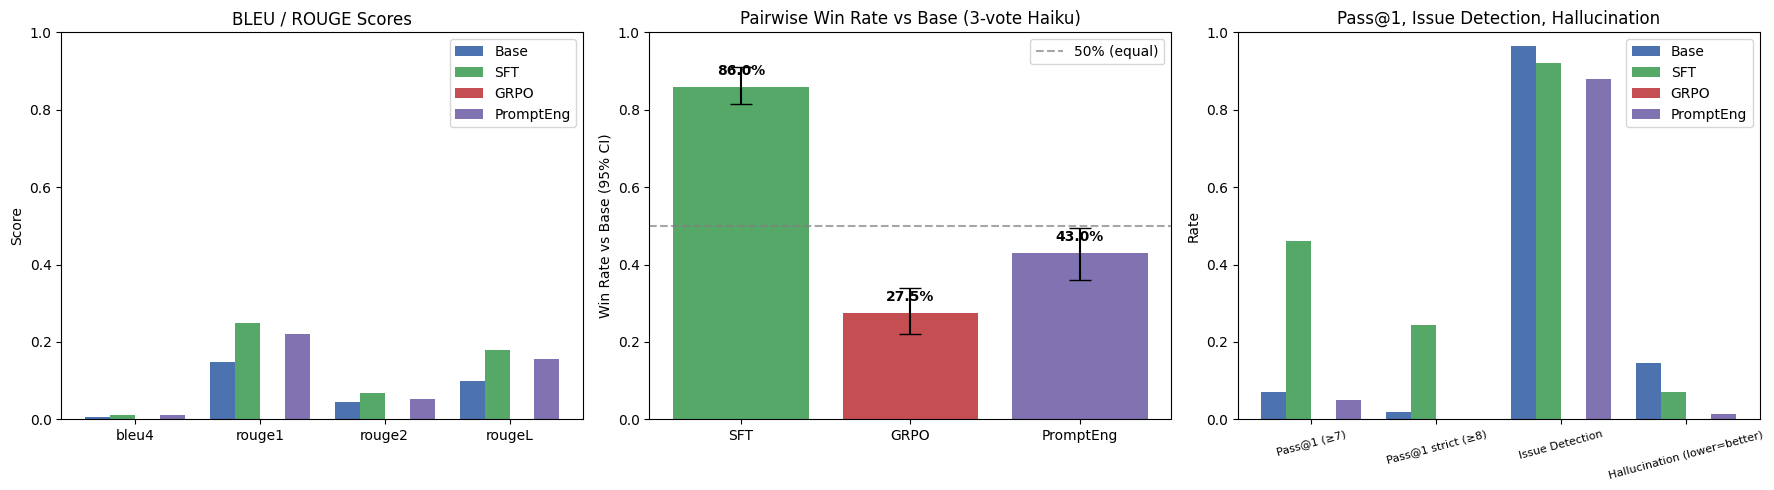

Charts saved to eval_results.png
✓ Chart logged to https://wandb.ai/deepanathan-rajendiran-university-at-buffalo/code-reviewer-eval/runs/gw03yy5n


In [ ]:
# ===== CELL 9: Results Table + Bar Charts =====
import matplotlib.pyplot as plt
import numpy as np, wandb

# Detect whether the prompt-engineering baseline (Cell 7d) ran in this session.
# If it did, include PromptEng as a 4th column; otherwise show the 3-model table.
HAS_PE = "pe_metrics" in dir() and isinstance(pe_metrics, dict)

if HAS_PE:
    all_metrics = {"Base": base_metrics, "SFT": sft_metrics,
                   "GRPO": grpo_metrics, "PromptEng": pe_metrics}
    models  = ["Base", "SFT", "GRPO", "PromptEng"]
    colors  = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
else:
    all_metrics = {"Base": base_metrics, "SFT": sft_metrics, "GRPO": grpo_metrics}
    models  = ["Base", "SFT", "GRPO"]
    colors  = ["#4C72B0", "#55A868", "#C44E52"]

# --- Combined Results Table ---
print("=" * 92)
if HAS_PE:
    hdr = (f"{'Metric':<22} {'Base':>9} {'SFT':>9} {'GRPO':>9} {'PromptEng':>10}  "
           f"{'SFT Δ':>8} {'PE Δ':>8} {'SFT-PE':>8}")
else:
    hdr = (f"{'Metric':<22} {'Base':>9} {'SFT':>9} {'GRPO':>9}  "
           f"{'SFT Δ':>8} {'GRPO Δ':>8}")
print(hdr); print("=" * len(hdr))

for m in ["bleu4", "rouge1", "rouge2", "rougeL", "haiku_mean",
          "pass_at_1", "pass_at_1_strict", "issue_detection",
          "specificity_rate", "hallucination", "length_mean"]:
    vals = [all_metrics[mod][m] for mod in models]
    if HAS_PE:
        sft_delta = vals[1] - vals[0]
        pe_delta  = vals[3] - vals[0]
        sft_vs_pe = vals[1] - vals[3]
        print(f"{m:<22} {vals[0]:>9.4f} {vals[1]:>9.4f} {vals[2]:>9.4f} {vals[3]:>10.4f}  "
              f"{sft_delta:>+8.4f} {pe_delta:>+8.4f} {sft_vs_pe:>+8.4f}")
    else:
        deltas = [vals[i] - vals[0] for i in range(1, 3)]
        signs  = ["+" if d >= 0 else "" for d in deltas]
        print(f"{m:<22} {vals[0]:>9.4f} {vals[1]:>9.4f} {vals[2]:>9.4f}  "
              f"{signs[0]}{deltas[0]:>7.4f} {signs[1]}{deltas[1]:>7.4f}")
print("-" * len(hdr))

# Pairwise win-rate footer
print(f"{'Haiku WR vs Base':<22} {'--':>9}", end="")
for stage in (["SFT", "GRPO"] if not HAS_PE else ["SFT", "GRPO", "PromptEng"]):
    if stage == "PromptEng":
        # PromptEng pairwise CI was computed in Cell 7d
        aw = pe_vs_base_results.count("A") / len(pe_vs_base_results) if 'pe_vs_base_results' in dir() else 0.0
        print(f" {aw:>9.1%}", end="")
    else:
        aw = wr[(stage, "Base")][0]
        print(f" {aw:>9.1%}", end="")
print()
print("=" * len(hdr))

if HAS_PE:
    # The key gauntlet number for the project's existence
    pe_vs_sft_a = pe_vs_sft_winrate[0] if 'pe_vs_sft_winrate' in dir() else None
    if pe_vs_sft_a is not None:
        print(f"\n► PromptEng vs SFT-v4 (3-vote pairwise): "
              f"PromptEng wins {pe_vs_sft_a:.1%} of the time")
        print("  >55% = prompt approach is competitive; <40% = SFT clearly wins.")

# --- Charts ---
n_charts = 3
fig, axes = plt.subplots(1, n_charts, figsize=(6 * n_charts, 5))

# Chart 1: BLEU & ROUGE grouped bars
text_metrics = ["bleu4", "rouge1", "rouge2", "rougeL"]
x = np.arange(len(text_metrics))
width = 0.8 / len(models)
for i, mod in enumerate(models):
    vals = [all_metrics[mod][m] for m in text_metrics]
    axes[0].bar(x + i * width, vals, width, label=mod, color=colors[i])
axes[0].set_ylabel("Score")
axes[0].set_title("BLEU / ROUGE Scores")
axes[0].set_xticks(x + width * (len(models) - 1) / 2)
axes[0].set_xticklabels(text_metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Chart 2: Haiku win-rates vs Base (with CI error bars)
stages    = ["SFT", "GRPO"] + (["PromptEng"] if HAS_PE else [])
win_rates = []
errs_lo, errs_hi = [], []
for s in stages:
    if s == "PromptEng":
        # Use the bootstrap CI computed in Cell 7d
        pe_wr_pt = pe_vs_base_results.count("A") / len(pe_vs_base_results) if 'pe_vs_base_results' in dir() else 0
        # pb_lo / pb_hi defined in Cell 7d
        lo = pb_lo if 'pb_lo' in dir() else pe_wr_pt
        hi = pb_hi if 'pb_hi' in dir() else pe_wr_pt
        win_rates.append(pe_wr_pt)
        errs_lo.append(pe_wr_pt - lo); errs_hi.append(hi - pe_wr_pt)
    else:
        win_rates.append(wr[(s, "Base")][0])
        pe_, lo, hi = ci_results[(s, "Base")]
        errs_lo.append(pe_ - lo); errs_hi.append(hi - pe_)

bar_colors = colors[1:1+len(stages)]
bars = axes[1].bar(stages, win_rates, color=bar_colors,
                   yerr=[errs_lo, errs_hi], capsize=8)
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="50% (equal)")
axes[1].set_ylabel("Win Rate vs Base (95% CI)")
axes[1].set_title("Pairwise Win Rate vs Base (3-vote Haiku)")
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, val in zip(bars, win_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f"{val:.1%}", ha="center", fontweight="bold")

# Chart 3: Pass@1 + Issue Detection
metric_pairs = [
    ("pass_at_1",        f"Pass@1 (≥{PASS_THRESHOLD})"),
    ("pass_at_1_strict", f"Pass@1 strict (≥{PASS_THRESHOLD_STRICT})"),
    ("issue_detection",  "Issue Detection"),
    ("hallucination",    "Hallucination (lower=better)"),
]
x3     = np.arange(len(metric_pairs))
width3 = 0.8 / len(models)
for i, mod in enumerate(models):
    vals = [all_metrics[mod][mp[0]] for mp in metric_pairs]
    axes[2].bar(x3 + i * width3, vals, width3, label=mod, color=colors[i])
axes[2].set_ylabel("Rate")
axes[2].set_title("Pass@1, Issue Detection, Hallucination")
axes[2].set_xticks(x3 + width3 * (len(models) - 1) / 2)
axes[2].set_xticklabels([mp[1] for mp in metric_pairs], fontsize=8, rotation=15)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.savefig("eval_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to eval_results.png")

if wandb.run is not None:
    wandb.log({"charts/aggregate_results": wandb.Image("eval_results.png")})
    print(f"✓ Chart logged to {wandb.run.url}")


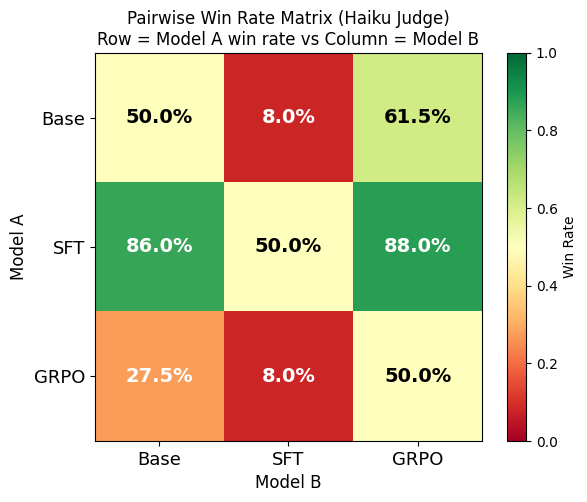

Heatmap saved to win_rate_heatmap.png


In [ ]:
# ===== CELL 8: Win-Rate Heatmap =====
import matplotlib.pyplot as plt
import numpy as np

models = ["Base", "SFT", "GRPO"]
n = len(models)
matrix = np.full((n, n), 0.5)  # diagonal = 0.5

model_idx = {m: i for i, m in enumerate(models)}
for (a, b), (aw, bw, tw) in wr.items():
    i, j = model_idx[a], model_idx[b]
    matrix[i][j] = aw
    matrix[j][i] = bw

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(models, fontsize=13)
ax.set_yticklabels(models, fontsize=13)
ax.set_xlabel("Model B", fontsize=12)
ax.set_ylabel("Model A", fontsize=12)
ax.set_title("Pairwise Win Rate Matrix (Haiku Judge)\nRow = Model A win rate vs Column = Model B", fontsize=12)

for i in range(n):
    for j in range(n):
        val = matrix[i][j]
        color = "white" if val > 0.65 or val < 0.35 else "black"
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                color=color, fontsize=14, fontweight="bold")

plt.colorbar(im, ax=ax, label="Win Rate")
plt.tight_layout()
plt.savefig("win_rate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved to win_rate_heatmap.png")

In [ ]:
# ===== CELL 9: Side-by-Side Examples =====
# Show 5 examples where SFT-v4 most outperforms Base by the 3-vote pairwise judge.
# (Was originally "Best GRPO Improvements" — switched to SFT since GRPO isn't
# running this pipeline; SFT-vs-Base verdicts come from sft_vs_base_results in Cell 6.)

print("=" * 80)
print("SIDE-BY-SIDE COMPARISON — 5 Best SFT-v4 Improvements (3-vote Haiku judge)")
print("=" * 80)

# Indices where SFT beat Base in the 3-vote pairwise comparison
sft_beats_base = [i for i, r in enumerate(sft_vs_base_results) if r == "A"]
# Among those, prioritise the ones with the largest absolute Haiku score jump
sft_beats_base.sort(key=lambda i: (sft_scores[i] - base_scores[i]), reverse=True)
show_indices = sft_beats_base[:5]

if not show_indices:
    print("\n(no SFT wins to display — check Cell 6's pairwise results)")
else:
    for rank, idx in enumerate(show_indices, 1):
        s_v_base = sft_vs_base_results[idx]
        print(f"\n{'=' * 80}")
        print(f"Example {rank}  |  SFT vs Base: {s_v_base}  "
              f"|  scores: base={base_scores[idx]} sft={sft_scores[idx]}")
        print(f"{'=' * 80}")
        print(f"\nDIFF (first 300 chars):\n{base_diffs[idx][:300]}")
        print(f"\nBASE: {base_preds[idx][:400]}")
        print(f"\nSFT:  {sft_preds[idx][:400]}")
        print(f"\nREF:  {base_refs[idx][:300]}")


SIDE-BY-SIDE COMPARISON — 5 Best SFT-v4 Improvements (3-vote Haiku judge)

Example 1  |  SFT vs Base: A  |  scores: base=1 sft=8

DIFF (first 300 chars):
@@ -105,7 +105,7 @@ def __init__(
         fpn_feature_size: int = 256,
         mask_feature_size: int = 256,
         no_object_weight: float = 0.1,
-        use_auxiliary_loss: bool = False,
+        auxiliary_loss: bool = False,

BASE: The change from `use_auxiliary_loss` to `auxiliary_loss` in the function parameter name is a good improvement for clarity and consistency with Python naming conventions. This makes the code easier to read and understand.

**Actionable Feedback:**
- **Approve**: The change improves readability and adheres to Python's naming standards.
- **Commit**: Proceed with the commit after ensuring all tests p

SFT:  Renaming `use_auxiliary_loss` to `auxiliary_loss` breaks backward compatibility for any caller passing the argument by name. Add a deprecation warning mapping the old name to the new one until remov

In [ ]:
# ===== CELL 10: Export Results + W&B Artifact + Resume Summary =====
import json, wandb, os

HAS_PE       = "pe_metrics" in dir() and isinstance(pe_metrics, dict)
HAS_NO_ISSUE = "base_fp" in dir() and "sft_fp" in dir()

all_metrics = {"Base": base_metrics, "SFT": sft_metrics, "GRPO": grpo_metrics}
if HAS_PE:
    all_metrics["PromptEng"] = pe_metrics

# ── Save to JSON locally ──────────────────────────────────────────────────
results = {
    "models":           list(all_metrics.keys()),
    "base_model":       "Qwen2.5-Coder-7B-Instruct",
    "eval_samples":     EVAL_SIZE,
    "judge":            "claude-haiku-4-5-20251001",
    "pass_thresholds":  {"pass_at_1": PASS_THRESHOLD, "pass_at_1_strict": PASS_THRESHOLD_STRICT},
    "metrics":          all_metrics,
    "pairwise_win_rates": {
        f"{a}_vs_{b}": {"a_wins": aw, "b_wins": bw, "ties": tw}
        for (a, b), (aw, bw, tw) in wr.items()
    },
    "pairwise_ci95": {
        f"{a}_vs_{b}": {"point": pe, "lo": lo, "hi": hi}
        for (a, b), (pe, lo, hi) in ci_results.items()
    },
    "judge_reliability_agreement": float(agree),
    "regression": {"sft": sft_stats, "grpo": grpo_stats},
    "failure_patterns": {
        pattern: {
            "base_pass_rate": sum(runs["base"]) / len(runs["base"]),
            "sft_pass_rate":  sum(runs["sft"])  / len(runs["sft"]),
            "grpo_pass_rate": sum(runs["grpo"]) / len(runs["grpo"]),
            "n": len(runs["base"]),
        }
        for pattern, runs in results_by_pattern.items()
    },
}

# Add no-issue probe results if Cell 7c ran
if HAS_NO_ISSUE:
    results["no_issue_probe"] = {
        "n_diffs":                len(NO_ISSUE_DIFFS),
        "base_hallucinated_rate": base_fp,
        "sft_hallucinated_rate":  sft_fp,
        "delta_sft_minus_base":   sft_fp - base_fp,
    }

# Add prompt-engineering baseline if Cell 7d ran
if HAS_PE:
    results["prompt_eng_baseline"] = {
        "metrics": pe_metrics,
        "pairwise_vs_sft": {
            "a_wins": pe_vs_sft_winrate[0],
            "b_wins": pe_vs_sft_winrate[1],
            "ties":   pe_vs_sft_winrate[2],
        } if 'pe_vs_sft_winrate' in dir() else None,
        "pairwise_vs_sft_ci": {"lo": pe_lo, "hi": pe_hi} if 'pe_lo' in dir() else None,
        "pairwise_vs_base_ci": {"lo": pb_lo, "hi": pb_hi} if 'pb_lo' in dir() else None,
    }

with open("eval_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("✓ Results saved to eval_results.json")

# ── Upload as W&B artifact so it persists on the run page ─────────────────
if wandb.run is not None:
    artifact = wandb.Artifact(
        name=f"eval-results-{wandb_run.name}",
        type="eval_results",
        description="Full eval metrics: aggregate, per-repo, pairwise CI, regression, "
                    "failure patterns, no-issue probe, prompt-eng baseline",
    )
    artifact.add_file("eval_results.json")
    for img_path in ("eval_results.png", "win_rate_heatmap.png"):
        if os.path.exists(img_path):
            artifact.add_file(img_path)
    wandb.log_artifact(artifact)
    print(f"✓ Artifact uploaded to W&B run {wandb.run.url}")

# ── Resume Summary (terminal-friendly) ────────────────────────────────────
print("\n" + "=" * 70)
print("RESUME SUMMARY")
print("=" * 70)
print("\nBuilt a multi-stage LLM fine-tuning pipeline for automated code review:")
print("  Base model : Qwen2.5-Coder-7B-Instruct")
print("  Pipeline   : Data rewrite (Gemini) → trace SFT (DeepSeek V4-Pro traces) → eval")
print("  Eval judge : Claude Haiku 4.5 (3-vote majority pairwise, n=200 samples)")
print("  Diagnostics: per-repo, regression, failure-pattern, no-issue probe,")
print("               judge reliability, prompt-engineering gauntlet\n")

print("Pairwise win-rates vs Base (3-vote, with 95% CI):")
for stage in ["SFT", "GRPO"]:
    aw, _, _ = wr[(stage, "Base")]
    pe, lo, hi = ci_results[(stage, "Base")]
    print(f"  {stage:<10} vs Base : {aw:.1%}  (CI95 [{lo:.1%}, {hi:.1%}])")
if HAS_PE and 'pb_lo' in dir():
    pe_wr = pe_vs_base_results.count("A") / len(pe_vs_base_results) if 'pe_vs_base_results' in dir() else 0
    print(f"  {'PromptEng':<10} vs Base : {pe_wr:.1%}  (CI95 [{pb_lo:.1%}, {pb_hi:.1%}])")

if HAS_PE and 'pe_vs_sft_winrate' in dir():
    print(f"\nGauntlet (prompt-eng vs SFT-v4): "
          f"{pe_vs_sft_winrate[0]:.1%} PromptEng wins  "
          f"(CI95 [{pe_lo:.1%}, {pe_hi:.1%}])")
    if pe_vs_sft_winrate[0] >= 0.5:
        print("  → SFT did NOT decisively beat the few-shot prompt; consider shipping the prompt.")
    else:
        print("  → SFT decisively beats the few-shot prompt; fine-tuning carrying real weight.")

print(f"\nPass@1 (Haiku score ≥ {PASS_THRESHOLD}/10):")
for mod, m in all_metrics.items():
    print(f"  {mod:<10} : pass@1 {m['pass_at_1']:.1%} (strict {m['pass_at_1_strict']:.1%}), "
          f"mean {m['haiku_mean']:.1f}/10, issue-detect {m['issue_detection']:.1%}, "
          f"halluc {m['hallucination']:.1%}")

print(f"\nJudge reliability: {agree:.1%} agreement between single-vote and 3-vote on 50 random pairs")

print(f"\nFailure-pattern pass rates (Base → SFT):")
for pattern, runs in results_by_pattern.items():
    n = len(runs["base"])
    b, s = sum(runs["base"]) / n, sum(runs["sft"]) / n
    arrow = "↑" if s > b else ("↓" if s < b else "=")
    print(f"  {pattern:<26} {b:>6.1%} → {s:>6.1%}  {arrow}")

if HAS_NO_ISSUE:
    print(f"\nNo-issue hallucination probe (20 clean diffs):")
    print(f"  Base hallucinated-bug rate: {base_fp:.1%}")
    print(f"  SFT  hallucinated-bug rate: {sft_fp:.1%}  ({sft_fp - base_fp:+.1%})")

print(f"\nRegression count (where SFT scored lower than Base): "
      f"{sft_stats['regressed']}/{EVAL_SIZE} samples")
print("=" * 70)

# ── Close W&B run ─────────────────────────────────────────────────────────
if wandb.run is not None:
    wandb.finish()
    print("\n✓ W&B run closed")


✓ Results saved to eval_results.json
✓ Artifact uploaded to W&B run https://wandb.ai/deepanathan-rajendiran-university-at-buffalo/code-reviewer-eval/runs/gw03yy5n

RESUME SUMMARY

Built a multi-stage LLM fine-tuning pipeline for automated code review:
  Base model : Qwen2.5-Coder-7B-Instruct
  Pipeline   : Data rewrite (Gemini) → trace SFT (DeepSeek V4-Pro traces) → eval
  Eval judge : Claude Haiku 4.5 (3-vote majority pairwise, n=200 samples)
  Diagnostics: per-repo, regression, failure-pattern, no-issue probe,
               judge reliability, prompt-engineering gauntlet

Pairwise win-rates vs Base (3-vote, with 95% CI):
  SFT        vs Base : 86.0%  (CI95 [81.5%, 91.0%])
  GRPO       vs Base : 27.5%  (CI95 [22.0%, 34.0%])
  PromptEng  vs Base : 43.0%  (CI95 [36.0%, 49.5%])

Gauntlet (prompt-eng vs SFT-v4): 13.5% PromptEng wins  (CI95 [8.5%, 19.0%])
  → SFT decisively beats the few-shot prompt; fine-tuning carrying real weight.

Pass@1 (Haiku score ≥ 7/10):
  Base       : pass@1 7.0%

agg/base/bleu4,██▁▁
agg/base/haiku_mean,▇█▃▁
agg/base/hallucination,▁▁██
agg/base/issue_detection,▁▁██
agg/base/length_mean,▁███
agg/base/length_median,██▁▁
agg/base/length_p95,▁▁██
agg/base/pass_at_1,█▁▁▆
agg/base/pass_at_1_strict,▁▁▆█
agg/base/rouge1,▁▁██
+161,...



✓ W&B run closed
